# Import Libraries

In [1]:
import numpy as np
import cvxpy as cp
import sympy as sp
from sympy.physics.vector import dynamicsymbols
from scipy.integrate import solve_ivp 
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# IEEE 14 bus network 
# to get test system
from pypower.api import case14, runpf, printpf, makeYbus
from pypower.idx_bus import *
from pypower.idx_brch import *
from pypower.idx_gen import *

# Helper functions
import helper_functions.inner_loop as il
import helper_functions.optimal_controller as oc
import helper_functions.multiple_inverter as mc
import helper_functions.plotting as plot
import helper_functions.droop_controller as dr

# Text display
from IPython.display import display, HTML, Math

# Initialize pretty printing with MathJax
sp.init_printing(use_latex="mathjax")

# Configure plot parameters
plt.rcParams.update({"font.size": 12, "font.family": "serif"})
dflt_figsize = (10.0, 6.0)
plt.rcParams['figure.figsize'] = dflt_figsize
plt.rcParams['figure.dpi'] = 200 
%matplotlib inline

In [2]:
def calculate_Zeq(R_f, L_f, R_g, L_g, C_f, omega):
    # Filter and grid impedances
    Z_f = R_f + 1j * omega * L_f
    Z_g = R_g + 1j * omega * L_g

    # Equivalent impedance
    Z_eq = Z_f + Z_g / (1 + 1j * omega * C_f * Z_g)

    return Z_eq

In [3]:
S_rated = 1200 # VA/W
S_base = S_rated # for per unit (3 phase)
v_nom_val = 120 # V
V_base = v_nom_val # for per unit (LN, RMS)
f_nom_val = 60 # Hz
omega_nom_val = 2 * np.pi * f_nom_val # rad/s
i_nom_val = S_rated/(3*v_nom_val) 
I_base = S_base/(3*V_base) # for per unit (phase, RMS)
Z_base = V_base / I_base # for per unit

Imag_lim_val = i_nom_val

# Filter and line parameters
r_i_val, r_g_val = 0.4, 0.9
l_i_val, l_g_val =  1.5e-3, 2e-3 
c_val = 10e-7 

# Equivalent impedance (using Edq)
Zeq = calculate_Zeq(r_i_val, l_i_val, r_g_val, l_g_val, c_val, omega_nom_val)
R, X = float(np.real(Zeq)), float(np.imag(Zeq))
L = X/(omega_nom_val)

# Equivalent impedance using Vc is simply R_i + j omega L_i

Vg = np.array([v_nom_val,0])
starttime = 0.05
endtime = 2

# Convert to pu
S_rated_pu = S_rated/S_base
v_nom_val_pu = v_nom_val / V_base
i_nom_val_pu = i_nom_val / I_base
Imag_lim_val_pu = i_nom_val_pu
r_i_val_pu, r_g_val_pu = r_i_val/Z_base, r_g_val/Z_base
l_i_val_pu, l_g_val_pu =  l_i_val/Z_base, l_g_val/Z_base # technically incorrect pu expression but works with code
c_val_pu = c_val * Z_base # (c_pu = c_val/Y_base = c_val * Z_base) # technically incorrect pu expression but works with code
L_pu = L/Z_base
R_pu = R/Z_base
Vg_pu = Vg / V_base

# A. Setpoint change (droop comparison)

## A.1 Outer Loop Only

In [33]:
# P, V^2 Tracking
perunit=True
x0 = np.array([0.75,0.3])
new_setpoints = [1, 1]
var_names = ["P",r"$V^2$"]

freq_outer = 100 #500
dt = 1/freq_outer

# OC parameters
alpha = 1
rho = 0.001

# Droop parameters
omega_c_val = 30 # Hz
m_p_val = 0.5 * 2 * np.pi # 0.5 Hz frequency droop 
m_v2_val = 0.05 # 5% voltage droop


ts_oc, Idq_of_t_oc,Vdq_of_t_oc,var1_of_t_oc,var2_of_t_oc = oc.oc_setpoint_change(new_setpoints, var_names, x0, R_pu, L_pu, Vg_pu,
                        Imag_lim_val_pu,omega_nom_val,
                        rho=rho,alpha=alpha, dt=dt, 
                        starttime=starttime, endtime=endtime, perunit=perunit)

ts_dr, Idq_of_t_dr, Vdqref_of_t_dr, Vdqactual_of_t_dr, P_of_t_dr, V2_of_t_dr, Vmag_of_t_dr, delta_of_t_dr = dr.pv2_droop_disturbance(new_setpoints, 
                        x0, R_pu, L_pu, Vg_pu, 
                        Imag_lim_val_pu, omega_nom_val, omega_c_val, m_p_val, m_v2_val,  
                        dt = dt, starttime = starttime, endtime=endtime, perunit=perunit, setpoint_change=True)


Average solve time: 6.67765879396985e-05, Longest solve time: 0.000263959
Average num_iters: 9.241206030150753, Largest num_iters: 12.0


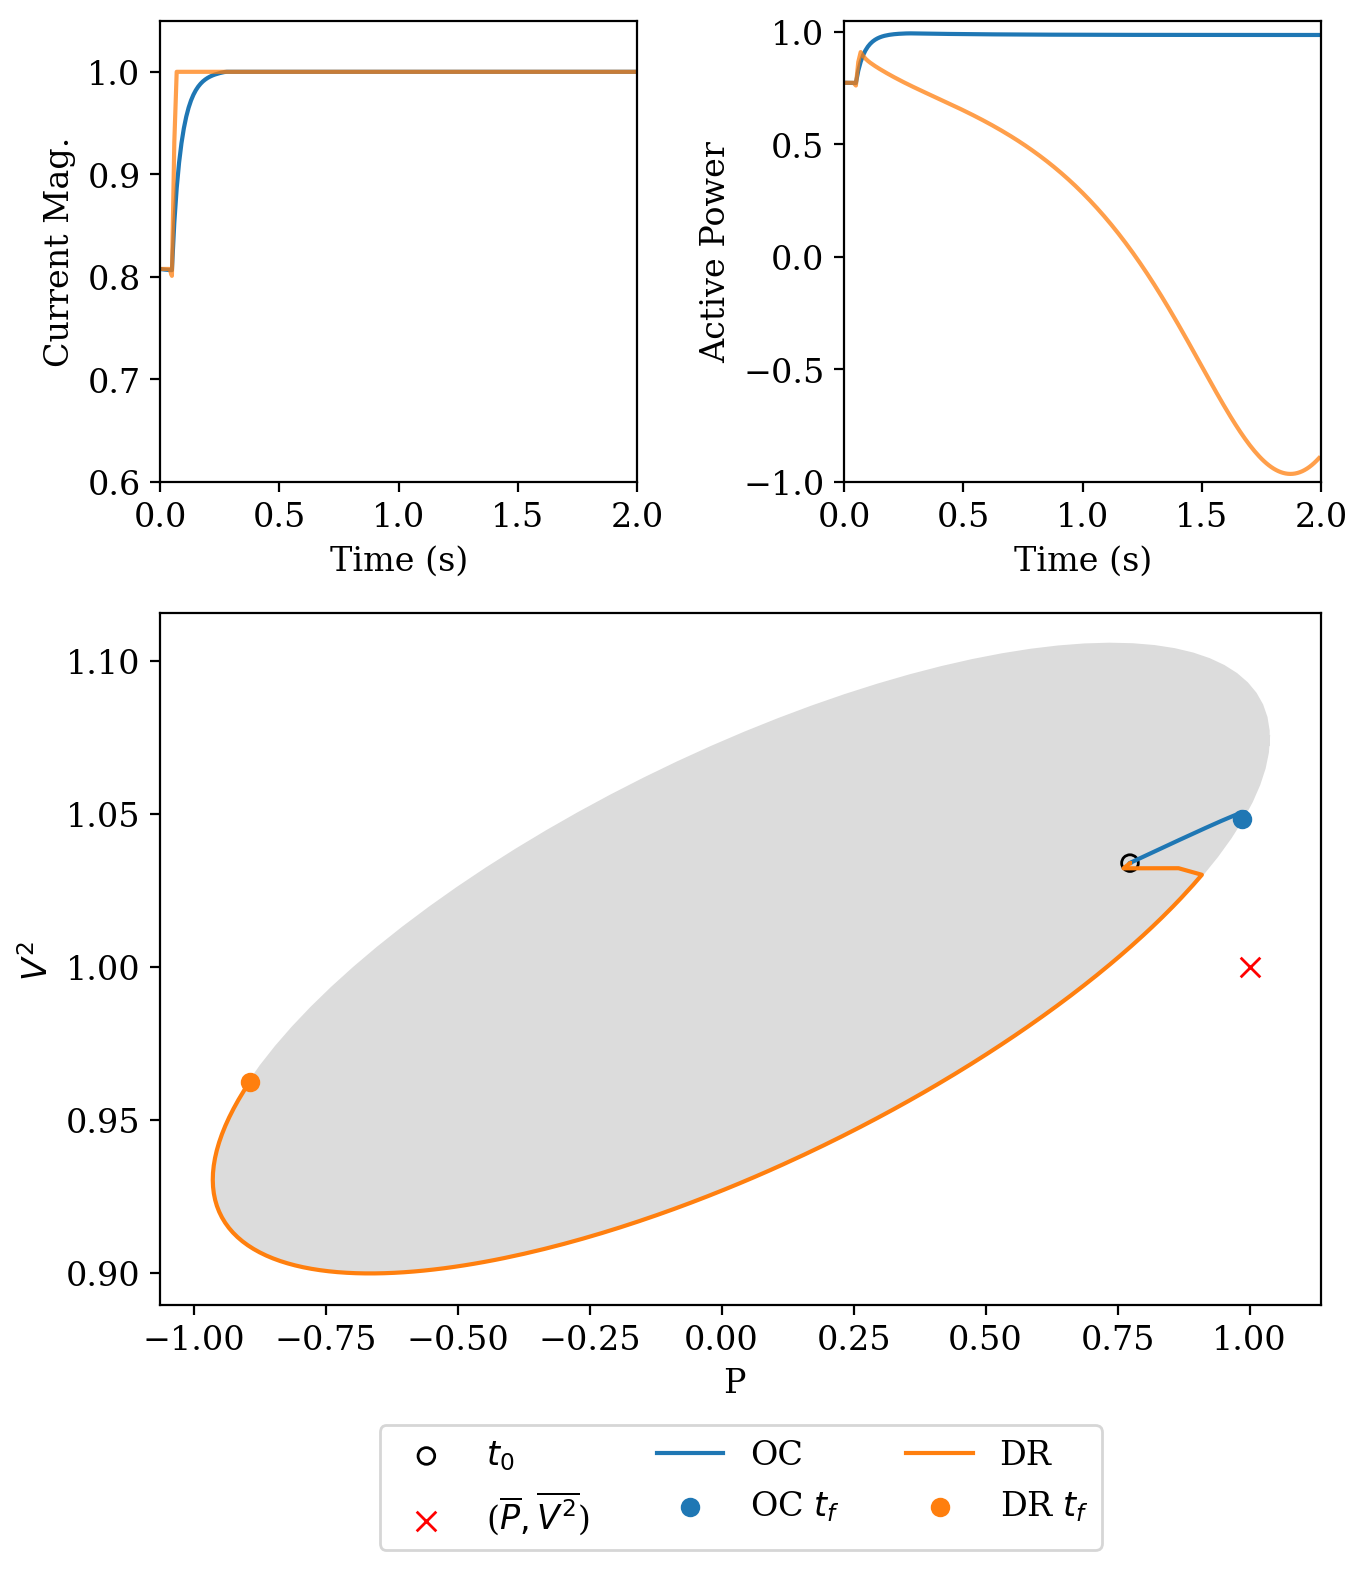

In [34]:
# HORIZONTAL: 
# fig,(ax1,ax2) = plt.subplots(1,2,figsize=(5,10))

# VERTICAL:
fig = plt.figure(figsize=(7, 8))
gs = gridspec.GridSpec(2, 2, figure=fig, height_ratios=[1, 1.5])

# Top plot (spans both columns)
ax1 = fig.add_subplot(gs[1, :])
ax2 = fig.add_subplot(gs[0,0])
ax2a = fig.add_subplot(gs[0,1])
#fig,(ax1,ax2) = plt.subplots(2,1,figsize=(5,10))
plot.plot_S(np.vstack([var1_of_t_oc,var2_of_t_oc]).T, new_setpoints,var_names, 
           Imag_lim_val_pu,v_nom_val_pu,L_pu,R_pu,omega_nom_val, 
           units = ["",""], ax = ax1, pu=perunit, second_trajectory=np.vstack([P_of_t_dr,V2_of_t_dr]).T, two_traj_labels=["OC","DR"])

#ax2.plot(ts_oc, np.ones(len(ts_oc))*Imag_lim_val_pu,'r--',label="Limit")
ax2.plot(ts_oc, np.linalg.norm(Idq_of_t_oc,axis=0),c='C0',label="OC")
ax2.plot(ts_dr, np.linalg.norm(Idq_of_t_dr,axis=0),c='C1',label="DR",alpha=0.75)
#ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),ncol=3)
ax2.set_xlabel("Time (s)")
ax2.set_ylabel(r"Current Mag.")

ax2a.plot(ts_oc, var1_of_t_oc,c='C0', label="OC")
ax2a.plot(ts_dr, P_of_t_dr,c='C1',alpha=0.75, label="DR")
#ax2a.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),ncol=3)
ax2a.set_xlabel("Time (s)")
ax2a.set_ylabel(r"Active Power")

# Zoom in 
xlim = [0,2]
ax2.set_xlim(xlim)
ax2a.set_xlim(xlim)
ax2.set_ylim([0.6,1.05])
ax2a.set_ylim([-1,1.05])

plt.tight_layout()
#plt.savefig("vert_setpoint_droop.png")

### A.1.1 Use $\mathbf{V}_c$ instead of $\mathbf{E}$

Average solve time: 7.309663316582915e-05, Longest solve time: 0.000265918
Average num_iters: 9.71859296482412, Largest num_iters: 12.0


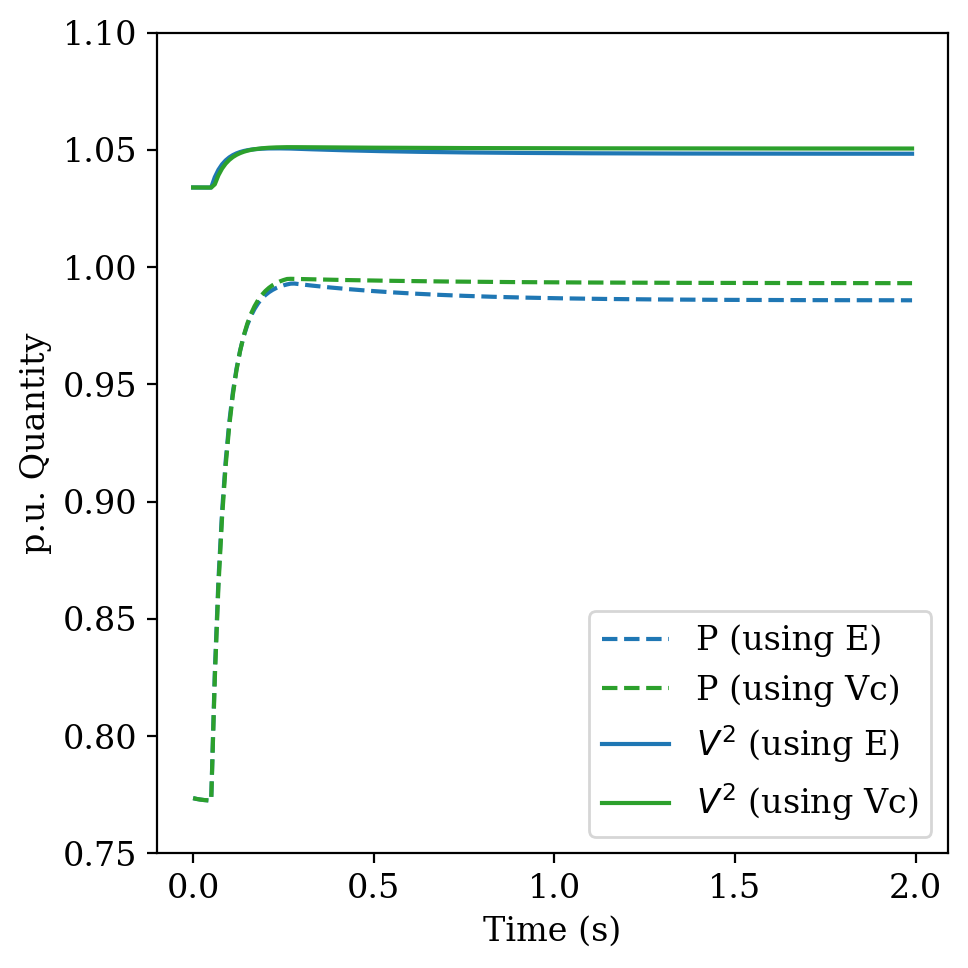

In [52]:
# Run directly after A.1 to use the same setup
ts_oc_Vc, Idq_of_t_oc_Vc,Vdq_of_t_oc_Vc,var1_of_t_oc_Vc,var2_of_t_oc_Vc = oc.oc_setpoint_change_Vc(new_setpoints, var_names, x0, 
                        R_pu, L_pu, r_i_val_pu, l_i_val_pu, Vg_pu,
                        Imag_lim_val_pu,omega_nom_val,
                        rho=rho,alpha=alpha, dt=dt, 
                        starttime=starttime, endtime=endtime, perunit=perunit)

fig,(ax2) = plt.subplots(1,1,figsize=(5,5))

#ax2.plot(ts_oc, np.ones(len(ts_oc))*Imag_lim_val_pu,'r--',label="Limit")
#ax1.plot(ts_oc, np.linalg.norm(Idq_of_t_oc,axis=0),c='C0',label=r"OC using $\mathbf{E}$")
#ax1.plot(ts_oc_Vc, np.linalg.norm(Idq_of_t_oc_Vc,axis=0),c='C2',label="OC using $V_c$")
#ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),ncol=3)
#ax1.set_xlabel("Time (s)")
#ax1.set_ylabel(r"Current Mag.")

ax2.plot(ts_oc, var1_of_t_oc,c='C0', linestyle="dashed", label="P (using E)")
ax2.plot(ts_oc_Vc, var1_of_t_oc_Vc,c='C2', linestyle="dashed",label="P (using Vc)")
ax2.plot(ts_oc, var2_of_t_oc,c='C0', linestyle='solid', label=r"$V^2$ (using E)")
ax2.plot(ts_oc_Vc, var2_of_t_oc_Vc,c='C2', linestyle="solid",label=r"$V^2$ (using Vc)")
#ax2a.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),ncol=3)
ax2.set_xlabel("Time (s)")
ax2.set_ylabel(r"p.u. Quantity")

# Zoom in 
xlim = [0,2]
#ax1.set_xlim(xlim)
#ax2.set_xlim(xlim)
#ax1.set_ylim([0.8,1.01])
ax2.set_ylim([0.75,1.1])
ax2.legend()

plt.tight_layout()
#plt.savefig("example_using_vc.png")

### A.1.2 Weak vs Strong Grid

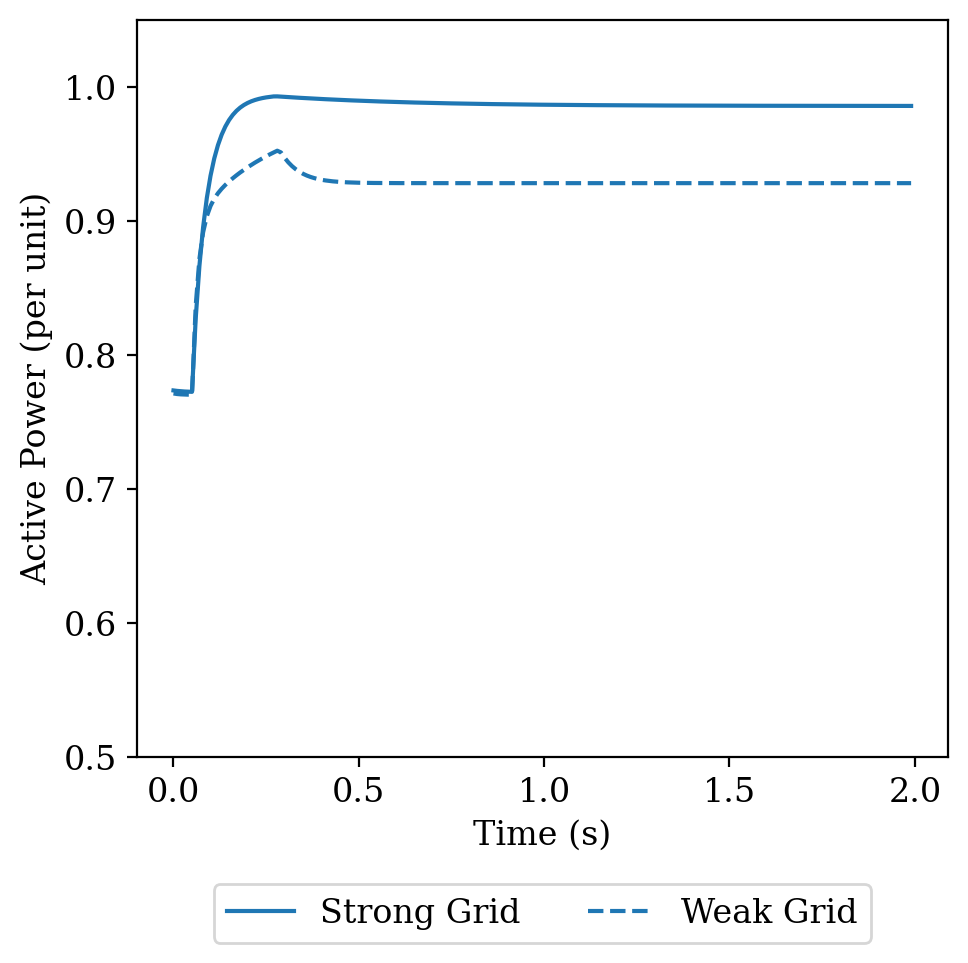

In [16]:
# P, V^2 Tracking
perunit=True
x0 = np.array([0.75,0.3])
new_setpoints = [1, 1]
var_names = ["P",r"$V^2$"]

freq_outer = 100 #500
dt = 1/freq_outer

# OC parameters
alpha = 1
rho = 0.001

# Droop parameters
omega_c_val = 30 # Hz
m_p_val = 0.5 * 2 * np.pi # 0.5 Hz frequency droop 
m_v2_val = 0.05 # 5% voltage droop


ts_oc, Idq_of_t_oc,Vdq_of_t_oc,var1_of_t_oc,var2_of_t_oc = oc.oc_setpoint_change(new_setpoints, var_names, x0, R_pu, L_pu, Vg_pu,
                        Imag_lim_val_pu,omega_nom_val,
                        rho=rho,alpha=alpha, dt=dt, 
                        starttime=starttime, endtime=endtime, perunit=perunit)
ts_weak, Idq_of_t_weak,Vdq_of_t_weak,var1_of_t_weak,var2_of_t_weak = oc.oc_setpoint_change(new_setpoints, var_names, x0/1.11, R_pu*5, L_pu*5, Vg_pu,
                        Imag_lim_val_pu,omega_nom_val,
                        rho=rho,alpha=alpha, dt=dt, 
                        starttime=starttime, endtime=endtime, perunit=perunit)

# fig,(ax1,ax2) = plt.subplots(1,2,figsize=(10,5))
fig,ax = plt.subplots(1,1,figsize=(5,5))
#ax.plot(ts_oc, np.linalg.norm(Idq_of_t_oc,axis=0),c='C0',label="Strong Grid")
#ax.plot(ts_weak, np.linalg.norm(Idq_of_t_weak,axis=0),c='C0',linestyle='dashed',label="Weak Grid")
ax.plot(ts_oc, var1_of_t_oc,c='C0',label="Strong Grid")
ax.plot(ts_weak, var1_of_t_weak,c='C0',linestyle='dashed',label="Weak Grid")
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),ncol=3)
ax.set_xlabel("Time (s)")
ax.set_ylabel(r"Active Power (per unit)")
ax.set_ylim([0.5,1.05])

plt.tight_layout()
#plt.savefig("vert_voltstep_droop.png")

## A.2 Include inner loop dynamics

In [36]:
# Compare to same example above without inner loop dynamics
freq_vol = 600 #800
freq_cur = 2000 #3000

ts_inner, Idq_of_t_inner,Vdq_of_t_inner,var1_of_t_inner,var2_of_t_inner = oc.oc_setpoint_change_with_il(new_setpoints, var_names, x0, 
                               r_i_val_pu, l_i_val_pu, r_g_val_pu, l_g_val_pu, c_val_pu, Vg_pu,
                               Imag_lim_val_pu,omega_nom_val,
                               rho=rho,alpha=alpha, dt=1/freq_outer, 
                               starttime=starttime, endtime=endtime/2,
                               freq_cur=freq_cur, freq_vol=freq_vol, perunit=perunit)

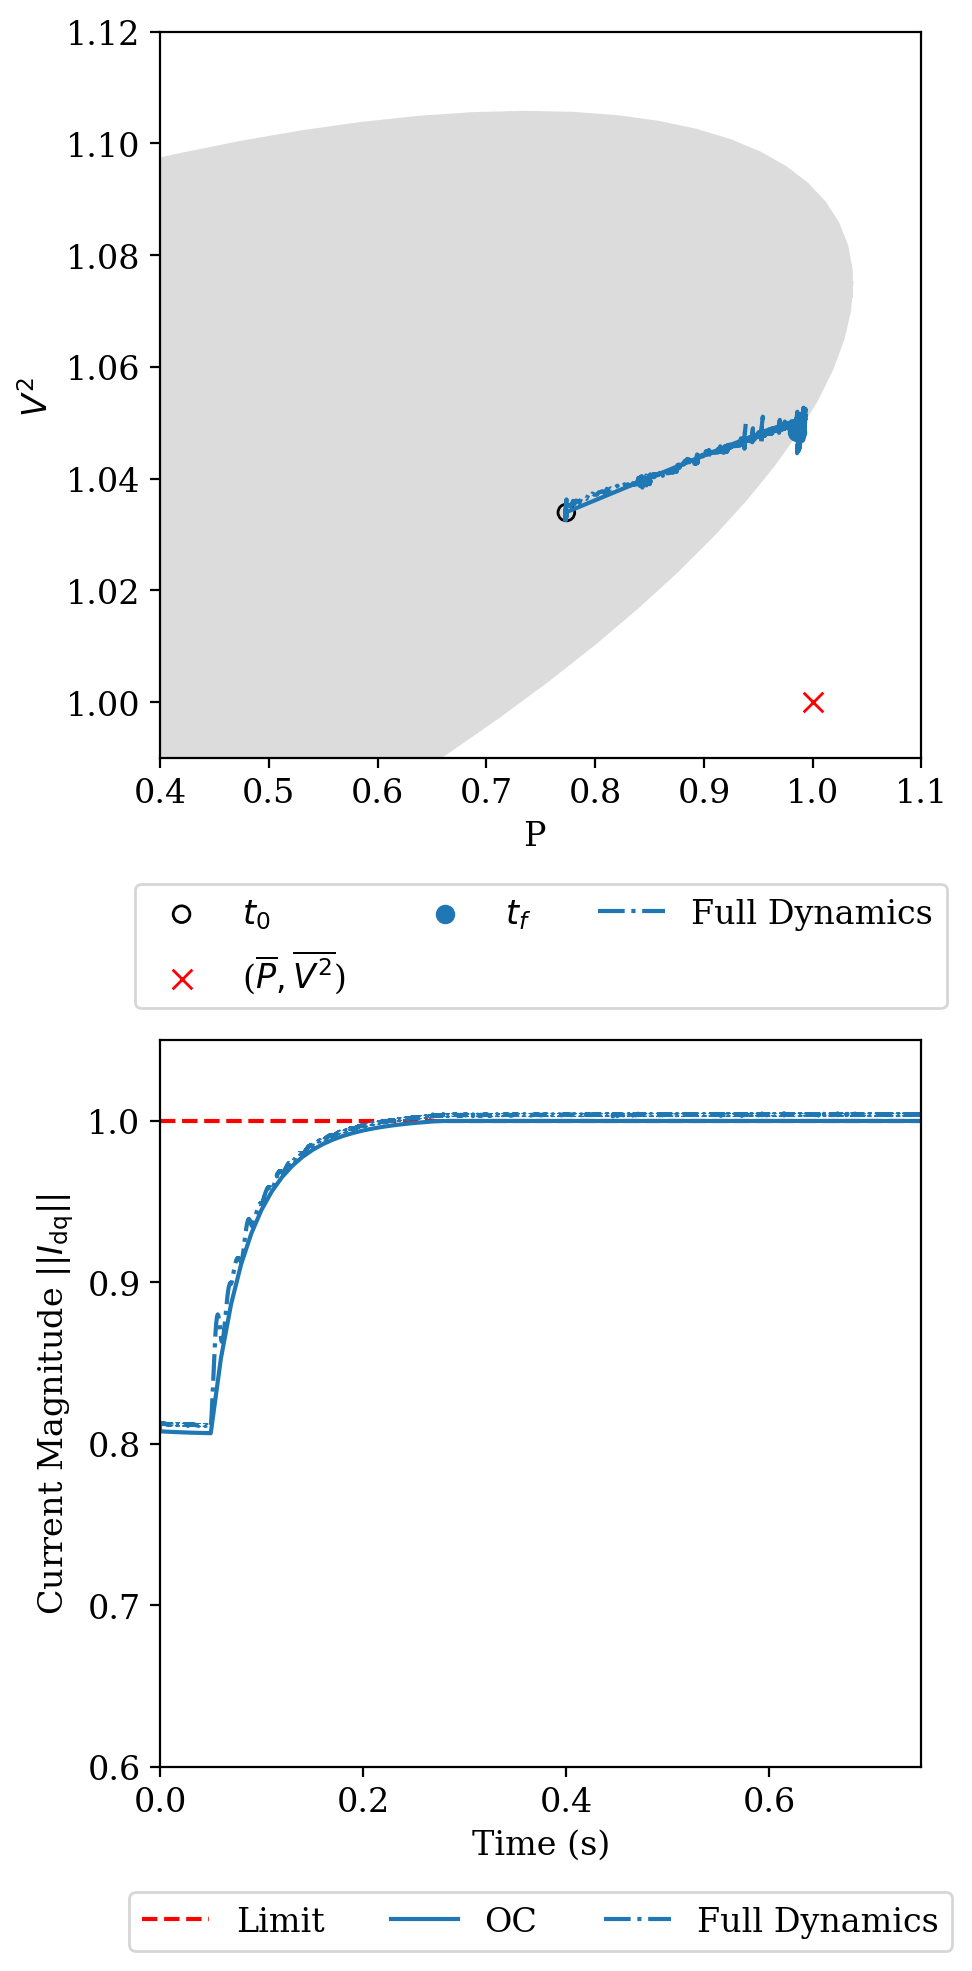

In [40]:
# Horizontal
# fig,(ax1,ax2) = plt.subplots(1,2,figsize=(10,5))

# Vertical
fig,(ax1,ax2) = plt.subplots(2,1,figsize=(5,10))
plot.plot_S(np.vstack([var1_of_t_oc,var2_of_t_oc]).T, new_setpoints,var_names, 
           Imag_lim_val_pu,v_nom_val_pu,L_pu,R_pu,omega_nom_val, 
           units = ["",""], ax = ax1, pu=perunit)
ax1.plot(var1_of_t_inner,var2_of_t_inner,c="C0",linestyle="-.",label="Full Dynamics")
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),ncol=3)

ax2.plot(ts_oc, np.ones(len(ts_oc))*Imag_lim_val_pu,'r--',label="Limit")
ax2.plot(ts_oc, np.linalg.norm(Idq_of_t_oc,axis=0),c='C0',label="OC")
ax2.plot(ts_inner, np.linalg.norm(Idq_of_t_inner,axis=0),c='C0',linestyle="-.",label="Full Dynamics")
ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),ncol=3)
ax2.set_ylim([0,1.05])
ax2.set_xlabel("Time (s)")
ax2.set_ylabel(r"Current Magnitude $||I_\mathrm{dq}||$")

# Zoomed in view
ax1.set_xlim([0.4,1.1])
ax1.set_ylim([0.99,1.12])

# Zoom in 
ax2.set_xlim([0,0.75])
ax2.set_ylim([0.6,1.05])

plt.tight_layout()
plt.savefig("vert_setpoint_innerloop.png")


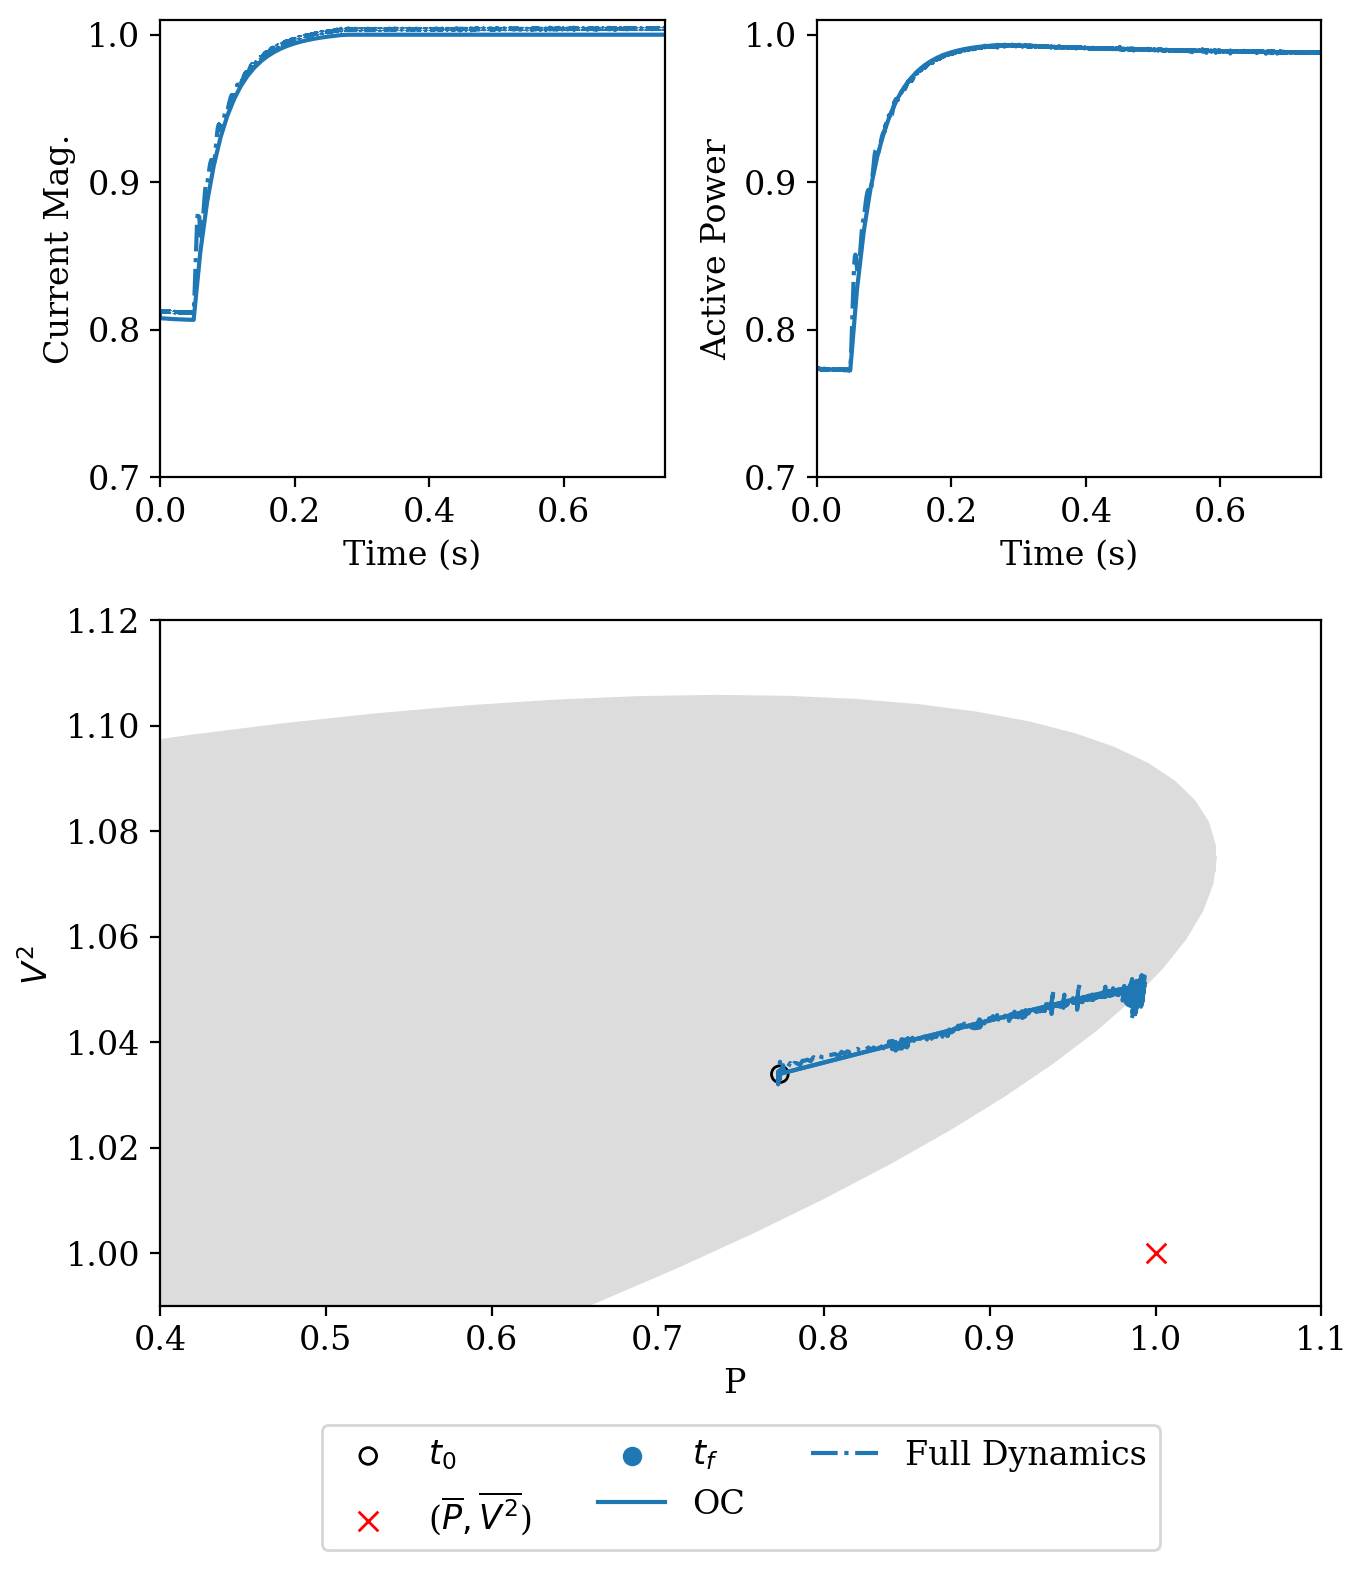

In [51]:
# HORIZONTAL: 
# fig,(ax1,ax2) = plt.subplots(1,2,figsize=(5,10))

# VERTICAL:
fig = plt.figure(figsize=(7, 8))
gs = gridspec.GridSpec(2, 2, figure=fig, height_ratios=[1, 1.5])

# Top plot (spans both columns)
ax1 = fig.add_subplot(gs[1, :])
ax2 = fig.add_subplot(gs[0,0])
ax2a = fig.add_subplot(gs[0,1])
#fig,(ax1,ax2) = plt.subplots(2,1,figsize=(5,10))
plot.plot_S(np.vstack([var1_of_t_oc,var2_of_t_oc]).T, new_setpoints,var_names, 
           Imag_lim_val_pu,v_nom_val_pu,L_pu,R_pu,omega_nom_val, 
           units = ["",""], ax = ax1, pu=perunit)
ax1.plot(var1_of_t_oc,var2_of_t_oc,c="C0",label="OC")
ax1.plot(var1_of_t_inner,var2_of_t_inner,c="C0",linestyle="-.",label="Full Dynamics")
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),ncol=3)

#ax2.plot(ts_oc, np.ones(len(ts_oc))*Imag_lim_val_pu,'r--',label="Limit")
ax2.plot(ts_oc, np.linalg.norm(Idq_of_t_oc,axis=0),c='C0',label="OC")
ax2.plot(ts_inner, np.linalg.norm(Idq_of_t_inner,axis=0),c='C0',linestyle="-.",label="Full Dynamics")
ax2.set_ylim([0,1.05])
ax2.set_xlabel("Time (s)")
ax2.set_ylabel(r"Current Mag.")

ax2a.plot(ts_oc, var1_of_t_oc,c='C0', label="OC")
ax2a.plot(ts_inner, var1_of_t_inner,c='C0',linestyle="-.",label="Full Dynamics")
#ax2a.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),ncol=3)
ax2a.set_xlabel("Time (s)")
ax2a.set_ylabel(r"Active Power")

# Zoom in 
xlim = [0,0.75]
ax2.set_xlim(xlim)
ax2a.set_xlim(xlim)
ax2.set_ylim([0.7,1.01])
ax2a.set_ylim([0.7,1.01])

# Zoomed in view
ax1.set_xlim([0.4,1.1])
ax1.set_ylim([0.99,1.12])

plt.tight_layout()
#plt.savefig("vert_setpoint_innerloop.png")

# B. Step change in grid voltage (droop comparison)

In [38]:
# P, V^2 Tracking
perunit=True
x0 = np.array([0.9,0.0])
Vg_newmag_pu = v_nom_val_pu * 0.83
new_setpoints = [Vg_newmag_pu, 0]
Vg_new = np.array(new_setpoints)
var_names = ["P",r"$V^2$"]

freq_outer = 100#500
dt = 1/freq_outer

# OC parameters
alpha = 1
rho = 0.001

# Droop parameters
omega_c_val = 30 # Hz
m_p_val = 0.5 * 2 * np.pi # 0.5 Hz frequency droop 
m_v2_val = 0.05 # 5% voltage droop


ts_oc, Idq_of_t_oc,Vdq_of_t_oc,var1_of_t_oc,var2_of_t_oc, Vg_of_t_oc = oc.oc_Edq_change(Vg_new, var_names, x0,R_pu,L_pu,Vg_pu, 
                  Imag_lim_val_pu,omega_nom_val,variance_size = 0.0,
                  rho=rho,alpha=alpha, dt=dt, 
                  starttime = starttime, endtime=endtime*2.6, perunit=perunit)

ts_dr, Idq_of_t_dr, Vdqref_of_t_dr, Vdqactual_of_t_dr, P_of_t_dr, V2_of_t_dr, Vmag_of_t_dr, delta_of_t_dr = dr.pv2_droop_disturbance(new_setpoints, 
                        x0, R_pu, L_pu, Vg_pu, 
                        Imag_lim_val_pu, omega_nom_val, omega_c_val, m_p_val, m_v2_val,  
                        dt = dt, starttime = starttime, endtime=endtime*2.6, perunit=perunit, setpoint_change=False)


Average solve time: 6.554320809248554e-05, Longest solve time: 0.001223289
Average num_iters: 8.992292870905588, Largest num_iters: 10.0


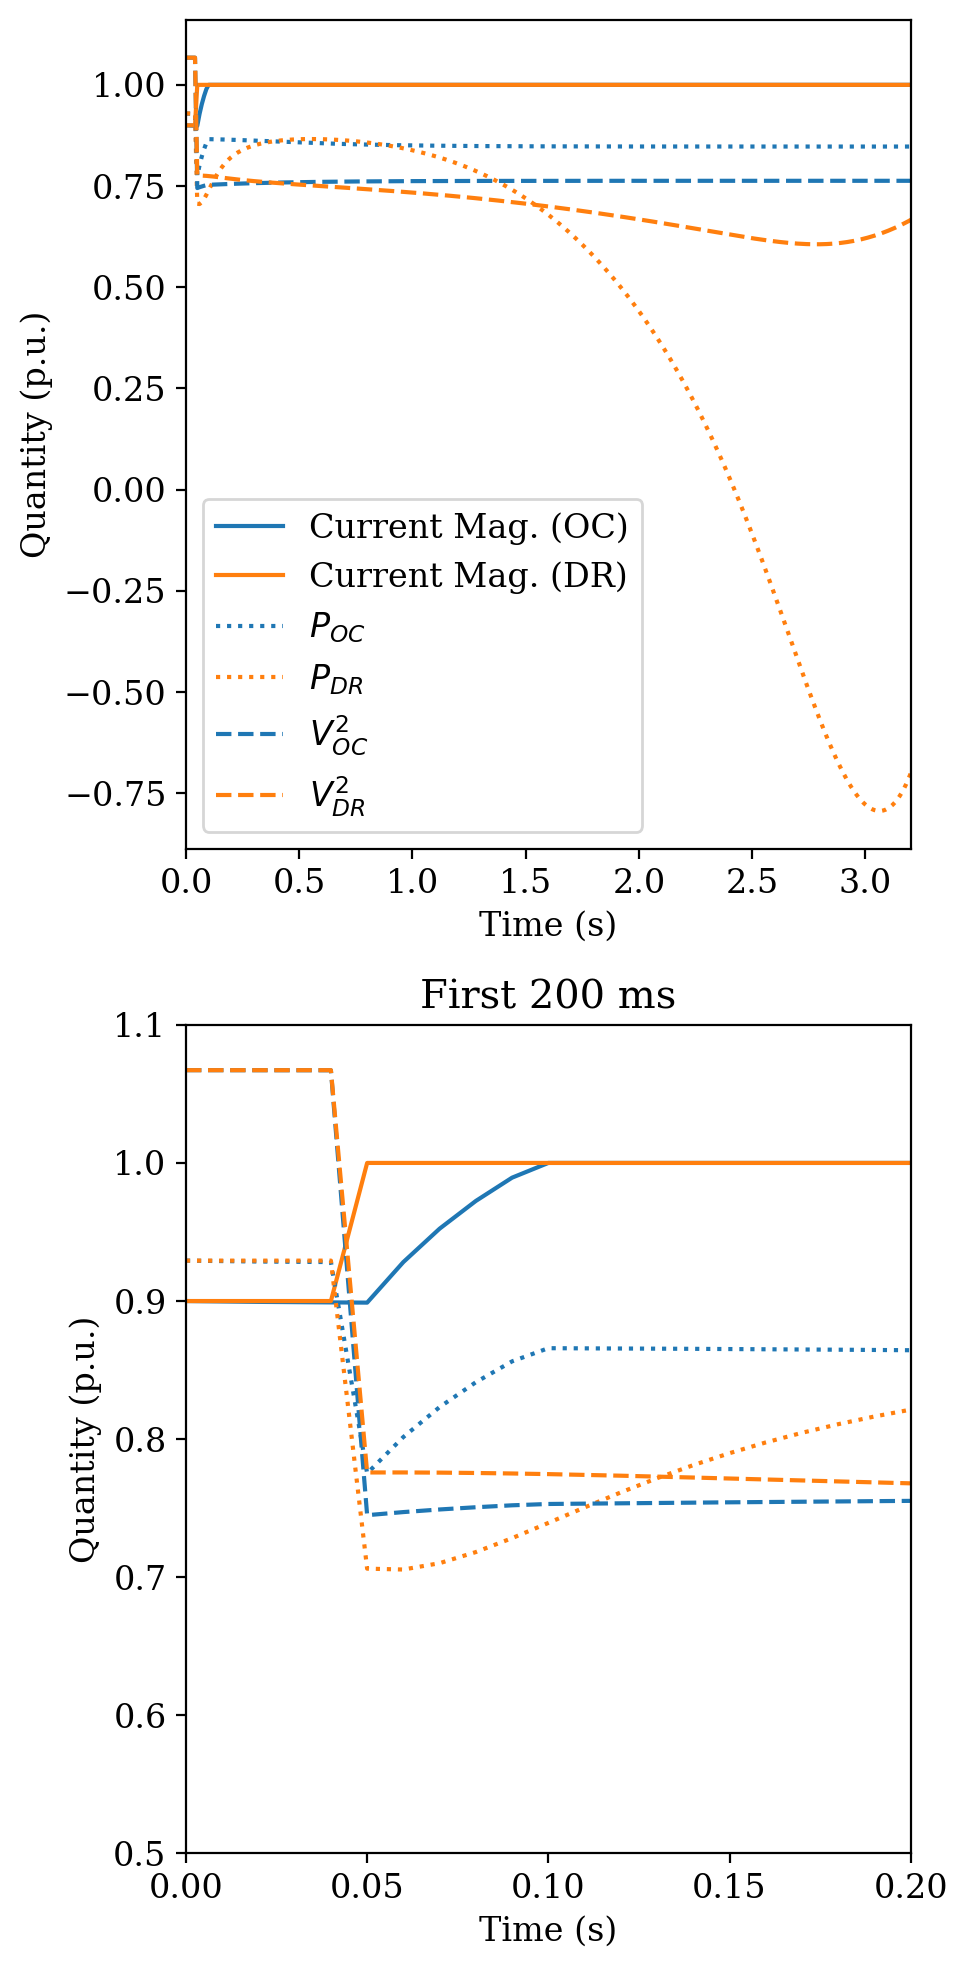

In [26]:
# fig,(ax1,ax2) = plt.subplots(1,2,figsize=(10,5))
fig,(ax1,ax2) = plt.subplots(2,1,figsize=(5,10))

ax1.plot(ts_oc, np.linalg.norm(Idq_of_t_oc,axis=0),c='C0',label=r"Current Mag. (OC)")
ax1.plot(ts_dr, np.linalg.norm(Idq_of_t_dr,axis=0),c='C1',label="Current Mag. (DR)")
ax1.plot(ts_oc, var1_of_t_oc,c='C0', linestyle='dotted', label=r"$P_{OC}$")
ax1.plot(ts_oc, P_of_t_dr,c='C1', linestyle='dotted', label=r"$P_{DR}$")
ax1.plot(ts_oc, var2_of_t_oc,c='C0', linestyle="dashed", label=r"$V^2_{OC}$")
ax1.plot(ts_oc, V2_of_t_dr,c='C1', linestyle="dashed", label=r"$V^2_{DR}$")
ax1.legend()
ax1.set_ylabel("Quantity (p.u.)")
ax1.set_xlabel("Time (s)")

ax2.plot(ts_oc, np.linalg.norm(Idq_of_t_oc,axis=0),c='C0',label=r"Current Mag. (OC)")
ax2.plot(ts_dr, np.linalg.norm(Idq_of_t_dr,axis=0),c='C1',label="Current Mag. (DR)")
ax2.plot(ts_oc, var1_of_t_oc,c='C0', linestyle='dotted', label=r"$P_{OC}$")
ax2.plot(ts_oc, P_of_t_dr,c='C1', linestyle='dotted', label=r"$P_{DR}$")
ax2.plot(ts_oc, var2_of_t_oc,c='C0', linestyle="dashed", label=r"$V^2_{OC}$")
ax2.plot(ts_oc, V2_of_t_dr,c='C1', linestyle="dashed", label=r"$V^2_{DR}$")
#ax2.legend()
ax2.set_ylabel("Quantity (p.u.)")
ax2.set_xlabel("Time (s)")

ax1.set_xlim([0,3.2])
ax2.set_xlim([0,0.2])
ax2.set_ylim([0.5,1.1])
ax2.set_title("First 200 ms")

plt.tight_layout()
plt.savefig("vert_voltstep_droop_new.png")

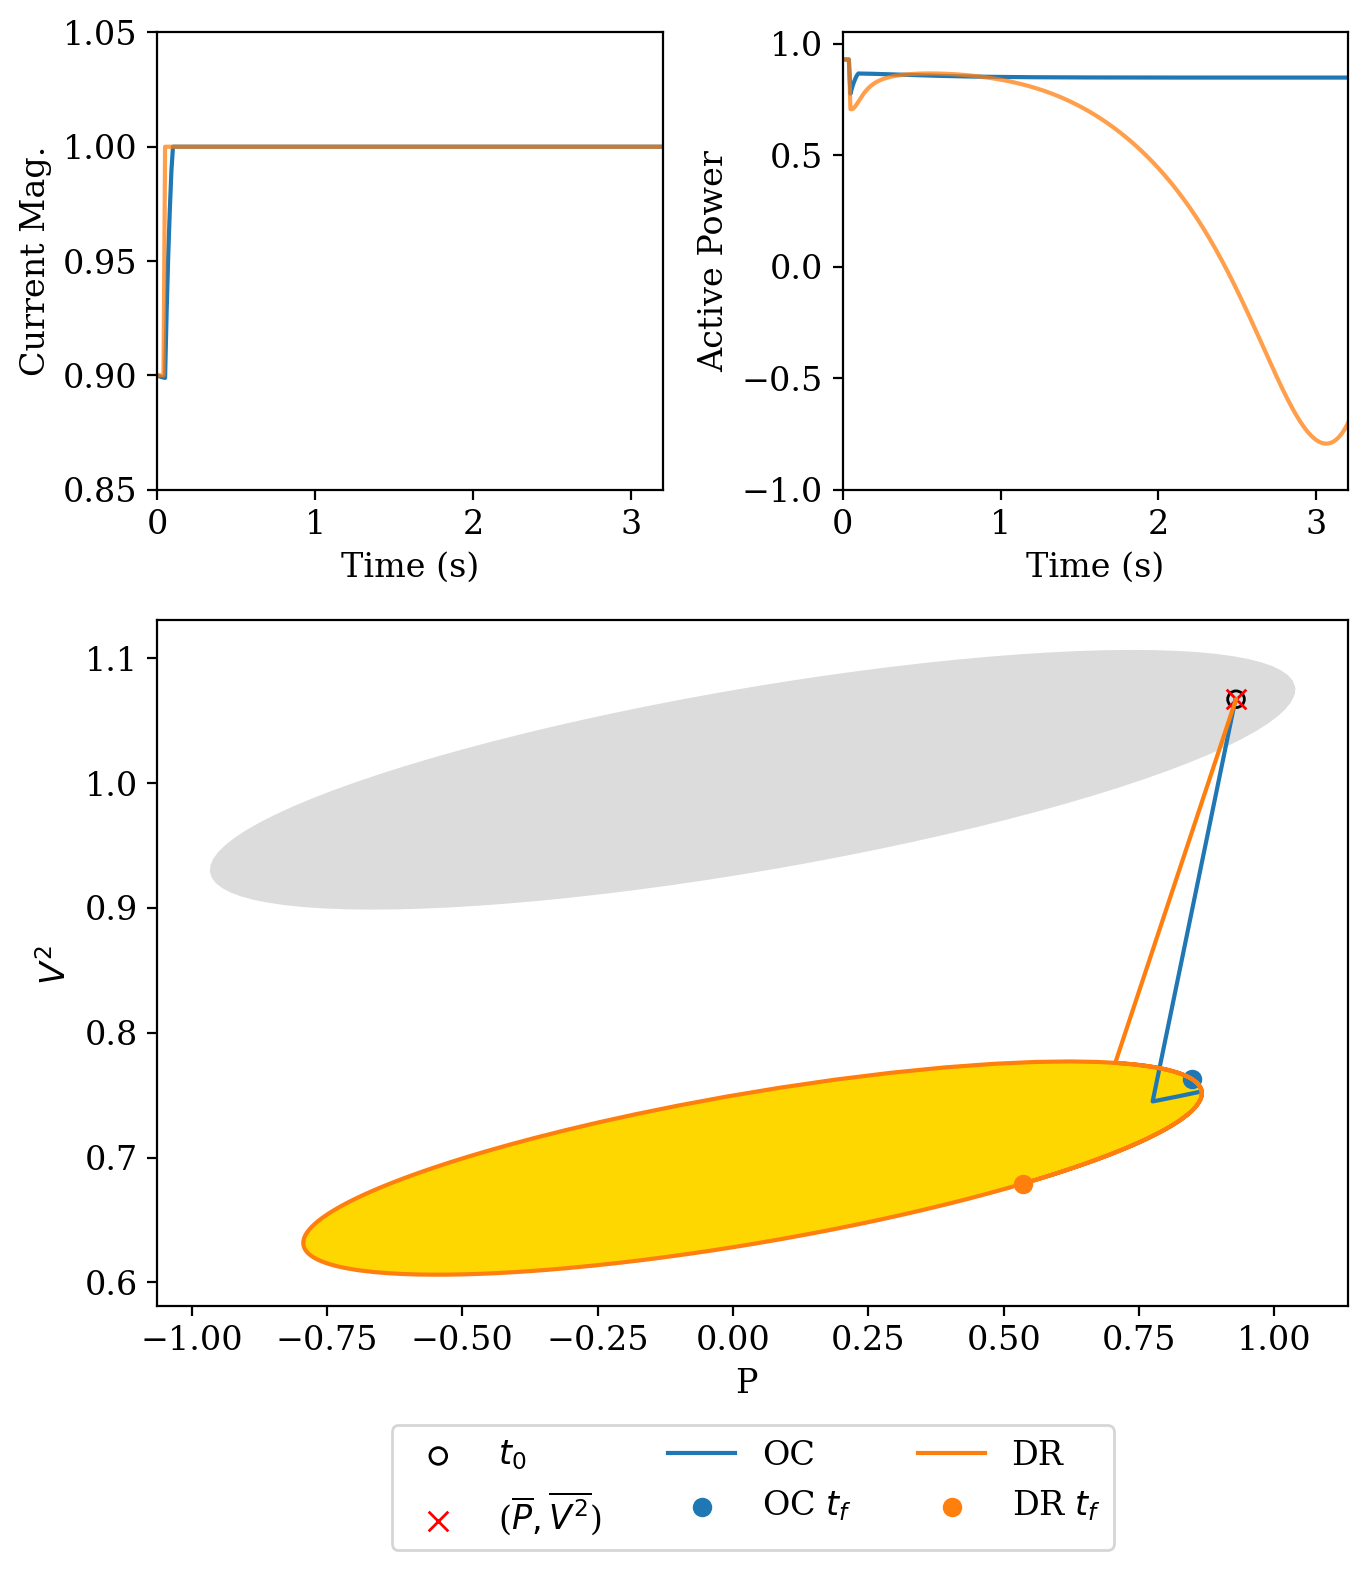

In [41]:
# HORIZONTAL: 
# fig,(ax1,ax2) = plt.subplots(1,2,figsize=(5,10))

# VERTICAL:
fig = plt.figure(figsize=(7, 8))
gs = gridspec.GridSpec(2, 2, figure=fig, height_ratios=[1, 1.5])

# Top plot (spans both columns)
ax1 = fig.add_subplot(gs[1, :])
ax2 = fig.add_subplot(gs[0,0])
ax2a = fig.add_subplot(gs[0,1])
disturbed_region_data = plot.set_S(var_names,Imag_lim_val_pu,Vg_newmag_pu,L_pu,R_pu,omega_nom_val,pu=perunit)
ax1.fill(disturbed_region_data[:,0],disturbed_region_data[:,1],c="gold")

plot.plot_S(np.vstack([var1_of_t_oc,var2_of_t_oc]).T, [var1_of_t_oc[0],var2_of_t_oc[0]],var_names, 
           Imag_lim_val_pu,v_nom_val_pu,L_pu,R_pu,omega_nom_val, 
           units = ["",""], ax = ax1, pu=perunit, second_trajectory=np.vstack([P_of_t_dr,V2_of_t_dr]).T, two_traj_labels=["OC","DR"])

#ax2.plot(ts_oc, np.ones(len(ts_oc))*Imag_lim_val_pu,'r--',label="Limit")
ax2.plot(ts_oc, np.linalg.norm(Idq_of_t_oc,axis=0),c='C0',label="OC")
ax2.plot(ts_dr, np.linalg.norm(Idq_of_t_dr,axis=0),c='C1',label="DR",alpha=0.75)
#ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),ncol=3)
ax2.set_xlabel("Time (s)")
ax2.set_ylabel(r"Current Mag.")

ax2a.plot(ts_oc, var1_of_t_oc,c='C0', label="OC")
ax2a.plot(ts_dr, P_of_t_dr,c='C1',alpha=0.75, label="DR")
#ax2a.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),ncol=3)
ax2a.set_xlabel("Time (s)")
ax2a.set_ylabel(r"Active Power")

# Zoom in 
xlim = [0,3.2]
ax2.set_xlim(xlim)
ax2a.set_xlim(xlim)
ax2.set_ylim([0.85,1.05])
ax2a.set_ylim([-1,1.05])

plt.tight_layout()
#plt.show()
plt.savefig("vert_voltstep_droop.png")


## B.2 Phase Jump in Grid Voltage

In [28]:
# P, V^2 Tracking
perunit=True
x0 = np.array([0.9,0.0])
Vg_newmag_pu = v_nom_val_pu * 0.75
new_setpoints = [0, Vg_newmag_pu] # 90 degree phase jump
Vg_new = np.array(new_setpoints)
var_names = ["P",r"$V^2$"]

freq_outer = 100#500
dt = 1/freq_outer

# OC parameters
alpha = 1
rho = 0.001

# Droop parameters
omega_c_val = 30 # Hz
m_p_val = 0.5 * 2 * np.pi # 0.5 Hz frequency droop 
m_v2_val = 0.05 # 5% voltage droop

endtime = 2


ts_oc, Idq_of_t_oc,Vdq_of_t_oc,var1_of_t_oc,var2_of_t_oc, Vg_of_t_oc = oc.oc_Edq_change(Vg_new, var_names, x0,R_pu,L_pu,Vg_pu, 
                  Imag_lim_val_pu,omega_nom_val,variance_size = 0.0,
                  rho=rho,alpha=alpha, dt=dt, 
                  starttime = starttime, endtime=endtime*5, perunit=perunit)

ts_dr, Idq_of_t_dr, Vdqref_of_t_dr, Vdqactual_of_t_dr, P_of_t_dr, V2_of_t_dr, Vmag_of_t_dr, delta_of_t_dr = dr.pv2_droop_disturbance(new_setpoints, 
                        x0, R_pu, L_pu, Vg_pu, 
                        Imag_lim_val_pu, omega_nom_val, omega_c_val, m_p_val, m_v2_val,  
                        dt = dt, starttime = starttime, endtime=endtime*5, perunit=perunit, setpoint_change=False)


Average solve time: 5.31375015015015e-05, Longest solve time: 0.000376666
Average num_iters: 7.012012012012012, Largest num_iters: 10.0


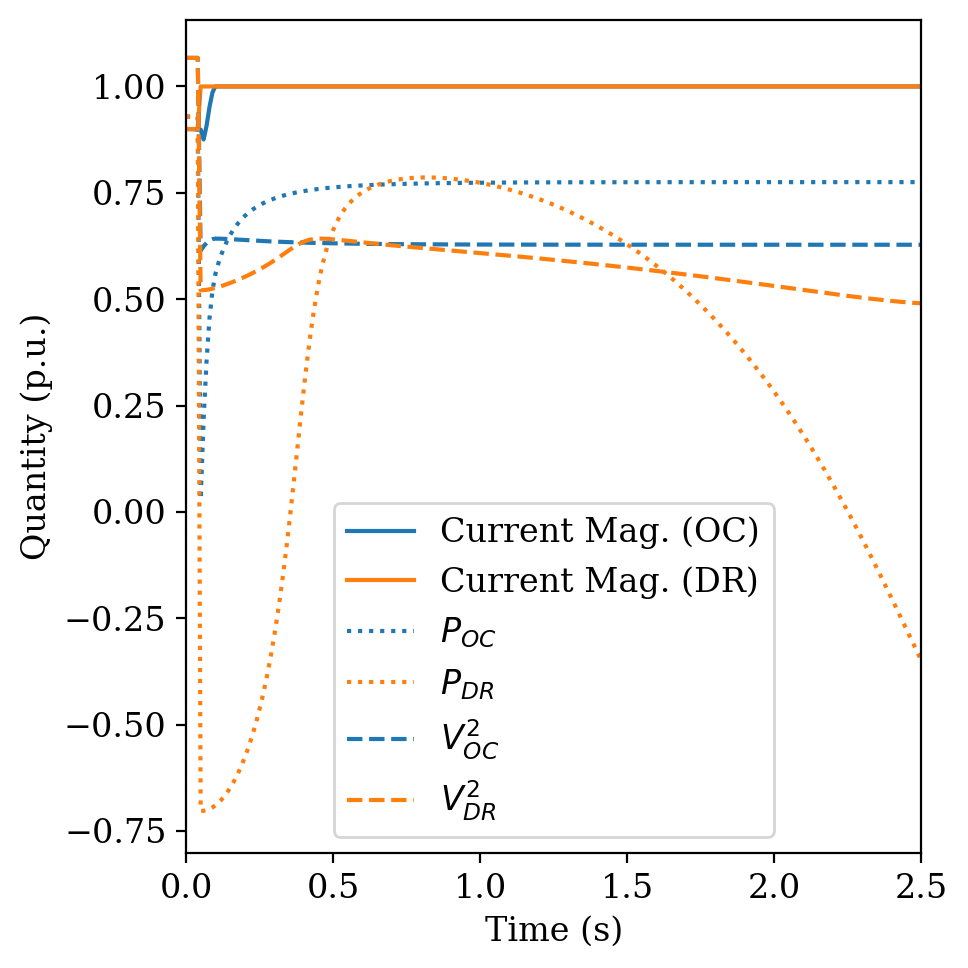

In [33]:
fig,(ax1) = plt.subplots(1,1,figsize=(5,5))

ax1.plot(ts_oc, np.linalg.norm(Idq_of_t_oc,axis=0),c='C0',label=r"Current Mag. (OC)")
ax1.plot(ts_dr, np.linalg.norm(Idq_of_t_dr,axis=0),c='C1',label="Current Mag. (DR)")
ax1.plot(ts_oc, var1_of_t_oc,c='C0', linestyle='dotted', label=r"$P_{OC}$")
ax1.plot(ts_oc, P_of_t_dr,c='C1', linestyle='dotted', label=r"$P_{DR}$")
ax1.plot(ts_oc, var2_of_t_oc,c='C0', linestyle="dashed", label=r"$V^2_{OC}$")
ax1.plot(ts_oc, V2_of_t_dr,c='C1', linestyle="dashed", label=r"$V^2_{DR}$")
ax1.legend()
ax1.set_ylabel("Quantity (p.u.)")
ax1.set_xlabel("Time (s)")

ax1.set_xlim([0,2.5])

plt.tight_layout()
plt.savefig("vert_phasejump_droop_new.png")

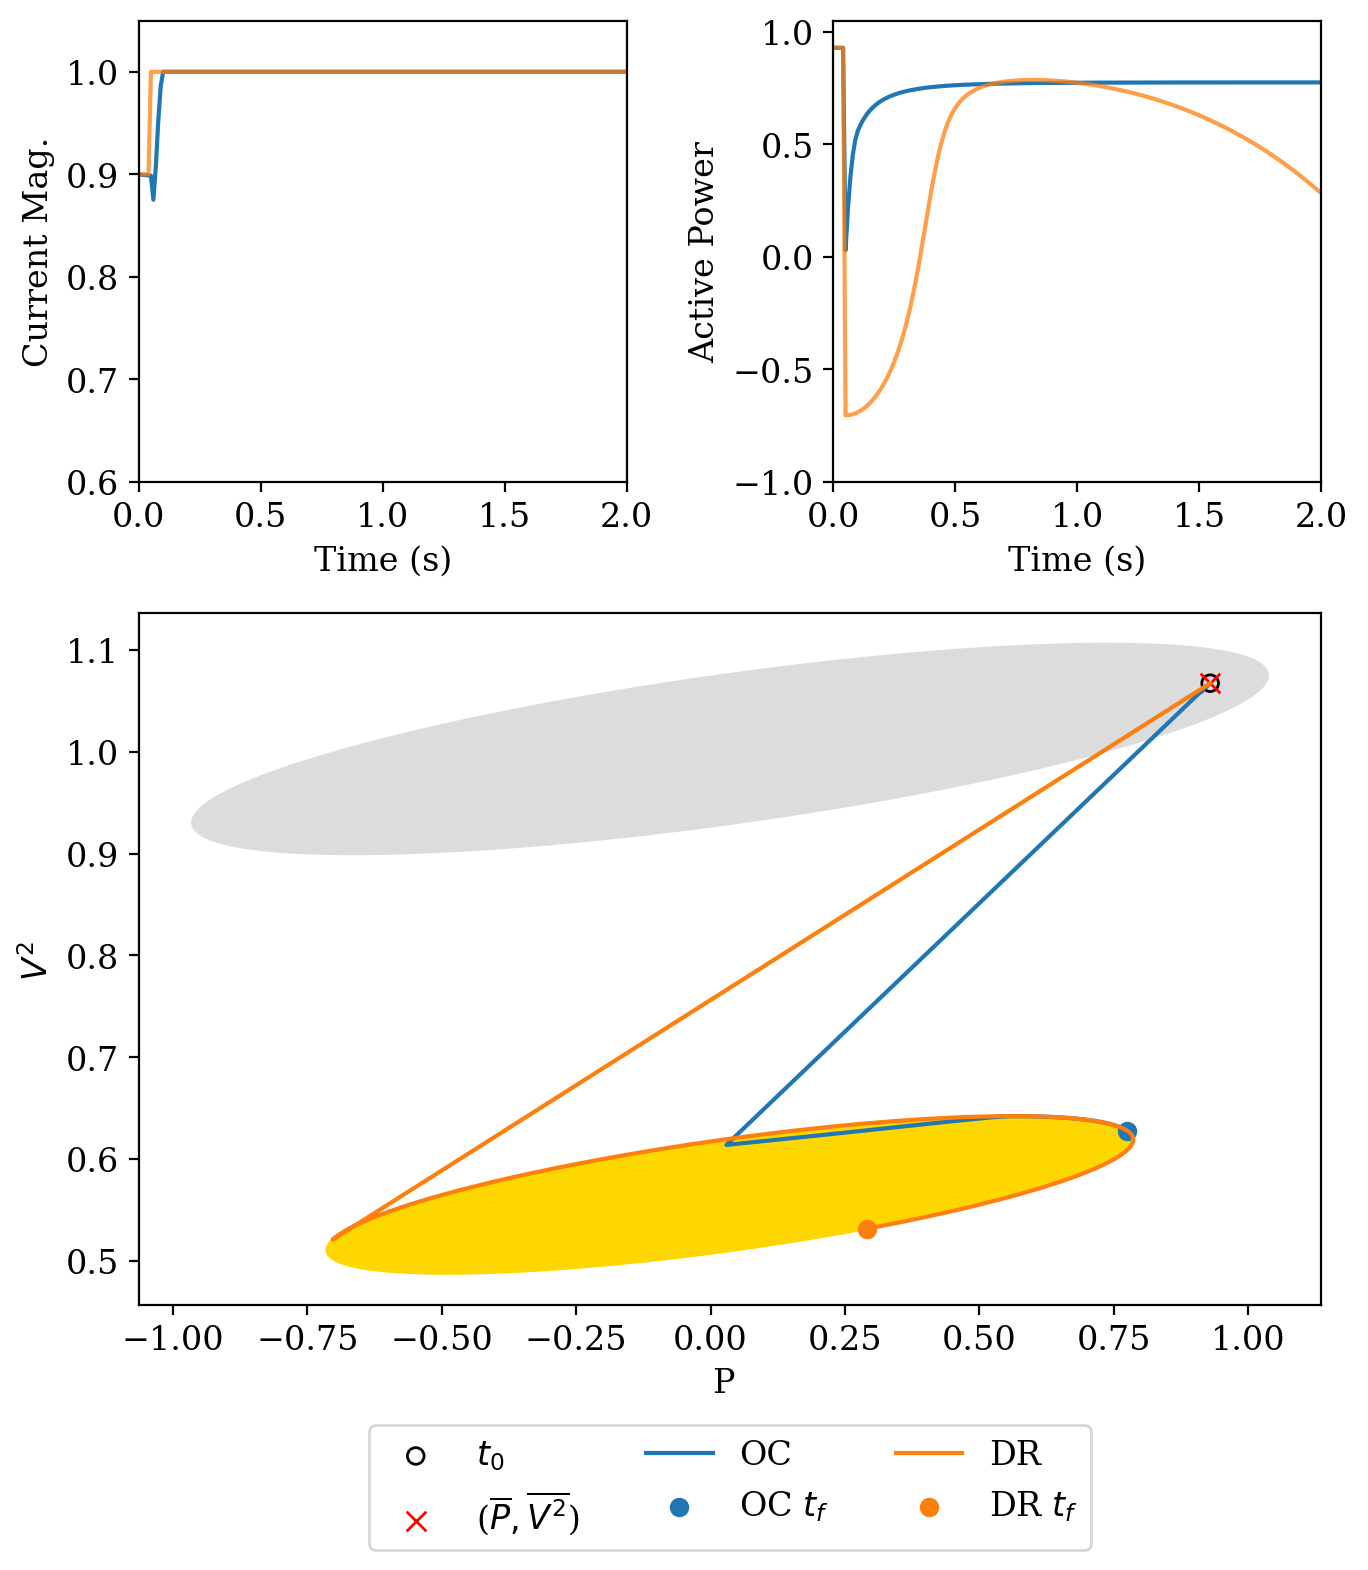

In [58]:
# HORIZONTAL: 
# fig,(ax1,ax2) = plt.subplots(1,2,figsize=(5,10))

# VERTICAL:
fig = plt.figure(figsize=(7, 8))
gs = gridspec.GridSpec(2, 2, figure=fig, height_ratios=[1, 1.5])

# Top plot (spans both columns)
ax1 = fig.add_subplot(gs[1, :])
ax2 = fig.add_subplot(gs[0,0])
ax2a = fig.add_subplot(gs[0,1])
disturbed_region_data = plot.set_S(var_names,Imag_lim_val_pu,Vg_newmag_pu,L_pu,R_pu,omega_nom_val,pu=perunit)
ax1.fill(disturbed_region_data[:,0],disturbed_region_data[:,1],c="gold")

plot.plot_S(np.vstack([var1_of_t_oc,var2_of_t_oc]).T, [var1_of_t_oc[0],var2_of_t_oc[0]],var_names, 
           Imag_lim_val_pu,v_nom_val_pu,L_pu,R_pu,omega_nom_val, 
           units = ["",""], ax = ax1, pu=perunit, second_trajectory=np.vstack([P_of_t_dr,V2_of_t_dr]).T, two_traj_labels=["OC","DR"])

#ax2.plot(ts_oc, np.ones(len(ts_oc))*Imag_lim_val_pu,'r--',label="Limit")
ax2.plot(ts_oc, np.linalg.norm(Idq_of_t_oc,axis=0),c='C0',label="OC")
ax2.plot(ts_dr, np.linalg.norm(Idq_of_t_dr,axis=0),c='C1',label="DR",alpha=0.75)
#ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),ncol=3)
ax2.set_xlabel("Time (s)")
ax2.set_ylabel(r"Current Mag.")

ax2a.plot(ts_oc, var1_of_t_oc,c='C0', label="OC")
ax2a.plot(ts_dr, P_of_t_dr,c='C1',alpha=0.75, label="DR")
#ax2a.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),ncol=3)
ax2a.set_xlabel("Time (s)")
ax2a.set_ylabel(r"Active Power")

# Zoom in 
xlim = [0,2]
ax2.set_xlim(xlim)
ax2a.set_xlim(xlim)
ax2.set_ylim([0.6,1.05])
ax2a.set_ylim([-1,1.05])

plt.tight_layout()
#plt.show()
#plt.savefig("example_phase_jump.png")


## B.3 Unbalanced Fault (line to line, positive sequence only) 

Note these results are not representative because our current simulation approach does not appropriately account for inner loop controls and power filtering that would be necessary to respond to double-frequency oscillations from the negative sequence component. 

In [86]:
freq_outer = 150 # change to 150
dt = 1/freq_outer
dt_abc = 1e-4

starttime = 0.5
recoverytime = 2.0
endtime = 3.0

# P, V^2 Tracking
perunit=True
x0 = np.array([0.9,0.0])
var_names = ["P",r"$V^2$"]

# OC parameters
alpha = 1
rho = 0.001

# THE FOLLOWING CODE SIMULATES A FAULT IN Vg (STATIONARY FRAME) AND PROCESSES IT INTO A DQ SIGNAL READ BY THE CONTROLLER
Vg_mag = 1
fault_pos_factor = 0.5
fault_neg_factor = 0.3

ts = np.arange(0,endtime,dt)
ts_abc = np.arange(0,endtime,dt_abc)

fault_idx_abc = (ts_abc > starttime) & (ts_abc < recoverytime)
ts_fault_abc = ts_abc[fault_idx_abc]

cos_signal = np.cos(omega_nom_val * ts_abc)
sin_signal = np.sin(omega_nom_val * ts_abc)

Vg_alpha = Vg_mag * cos_signal
Vg_beta = Vg_mag * sin_signal

Vg_alphabeta = np.vstack((Vg_alpha, Vg_beta))
Vg_alphabeta_neg = np.zeros((2,len(ts_abc)))

# Reduce positive sequence component magnitude during fault (if applicable)
Vg_alphabeta_neg[:,fault_idx_abc] = Vg_alphabeta[:,fault_idx_abc].copy() * fault_neg_factor
Vg_alphabeta_neg[1,fault_idx_abc] *= -1
Vg_alphabeta[:,fault_idx_abc] *= fault_pos_factor

# Add negative sequence component 
Vg_alphabeta += Vg_alphabeta_neg

# Convert to dq frame rotating at 60 Hz
Vg_d = Vg_alphabeta[0,:] * cos_signal + Vg_alphabeta[1,:] * sin_signal
Vg_q = -Vg_alphabeta[0,:] * sin_signal + Vg_alphabeta[1,:] * cos_signal

Vg_d_ctrl = np.interp(
    ts,
    ts_abc,
    Vg_d
)

Vg_q_ctrl = np.interp(
    ts,
    ts_abc,
    Vg_q
)

Vg_dq_ctrl = np.vstack((Vg_d_ctrl, Vg_q_ctrl))

# NOW SIMULATE
ts_oc, Idq_of_t_oc,Vdq_of_t_oc,var1_of_t_oc,var2_of_t_oc = oc.oc_Edq_change_customVg(Vg_dq_ctrl, var_names, x0,R_pu,L_pu,
                  Imag_lim_val,omega_nom_val, rho=rho,alpha=alpha, 
                  dt=dt,perunit=perunit)

Average solve time: 6.280190423162584e-05, Longest solve time: 0.000185167
Average num_iters: 9.385300668151448, Largest num_iters: 14.0


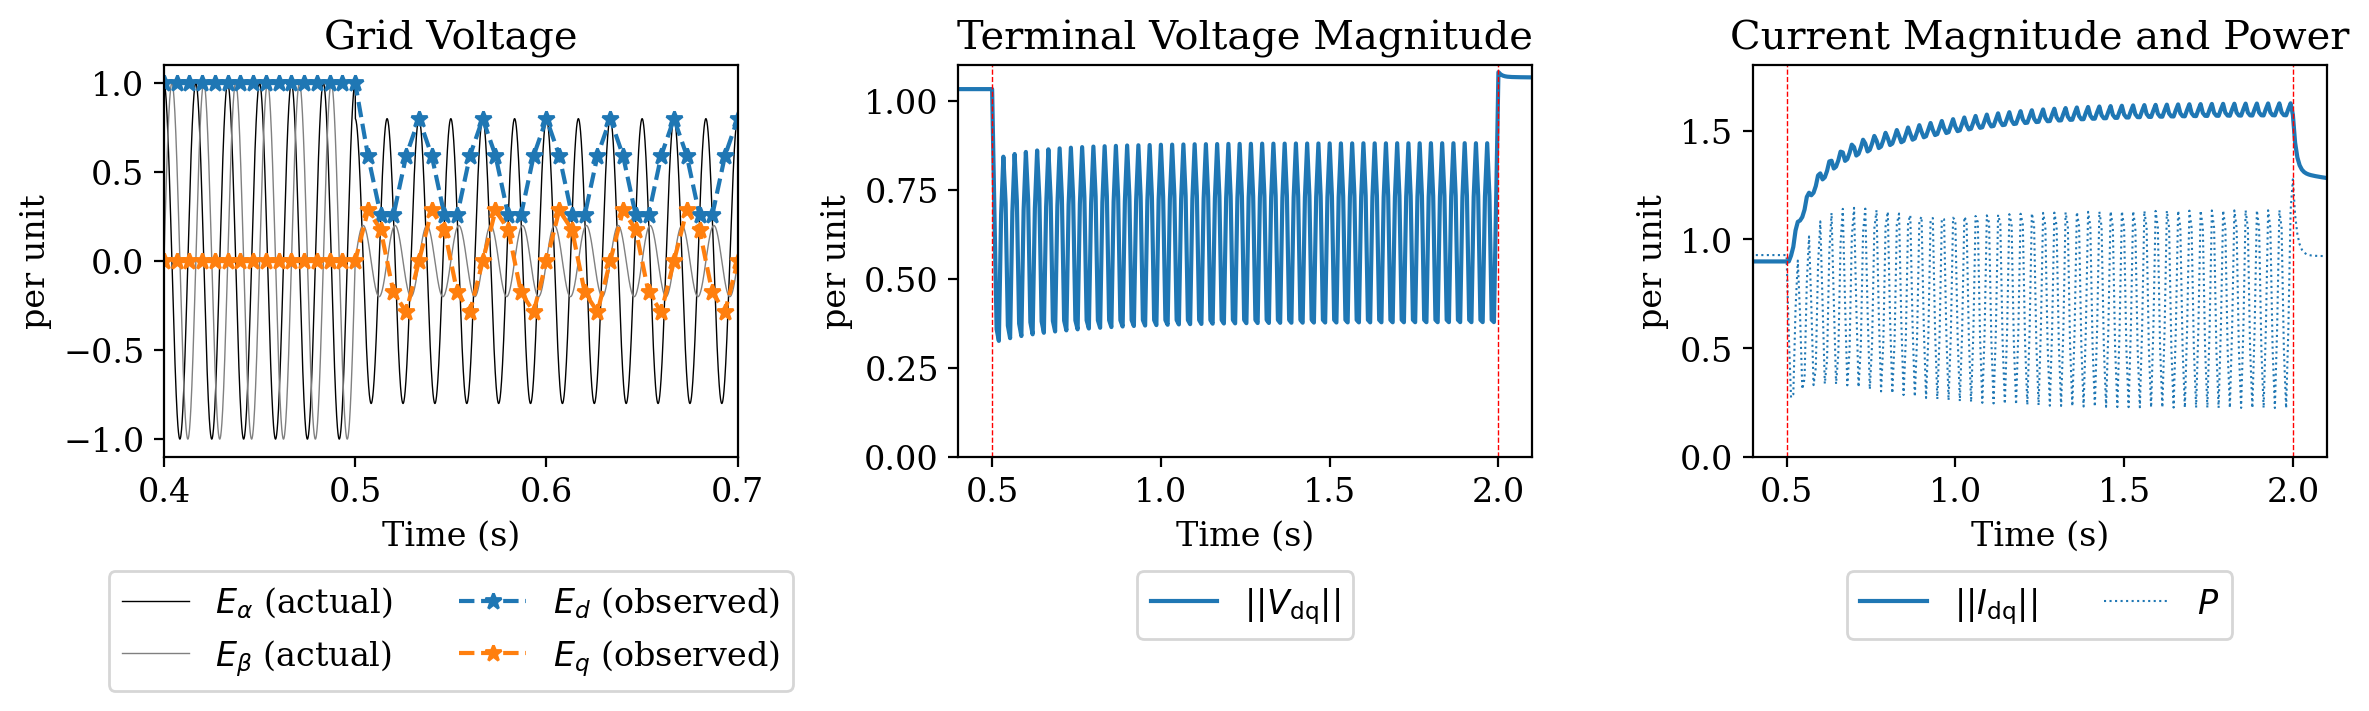

In [89]:
# Now plot it
# HORIZONTAL: 
fig,(ax1,ax2, ax3) = plt.subplots(1,3,figsize=(12,4))
ylim2 = [0,1.1]
ylim3 = [0,1.8]
xlim = [0.4,2.1]

# Stationary frame plot of grid voltage
ax1.plot(ts_abc, Vg_alphabeta[0,:],c='black',label=r"$E_\alpha$ (actual)",linewidth=0.5)
ax1.plot(ts_abc, Vg_alphabeta[1,:],c='gray',label=r"$E_\beta$ (actual)",linewidth=0.5)
ax1.plot(ts_oc, Vg_d_ctrl,c="C0",marker="*",linestyle="dashed",label=r"$E_d$ (observed)")
ax1.plot(ts_oc, Vg_q_ctrl,c="C1",marker="*",linestyle="dashed",label=r"$E_q$ (observed)")
ax1.set_title("Grid Voltage")
ax1.set_ylabel("per unit")
ax1.set_xlabel("Time (s)")
ax1.set_xlim([0.4,0.7])
ax1.legend(loc="upper center",
    bbox_to_anchor=(0.5, -0.25),
    ncol=2)

ax2.plot(ts_oc, np.linalg.norm(Vdq_of_t_oc,axis=0),c='C0',label="$||V_\mathrm{dq}||$")
ax2.set_ylabel("per unit")
ax2.set_xlabel("Time (s)")
ax2.set_ylim(ylim2)
ax2.set_xlim(xlim)
ax2.set_title("Terminal Voltage Magnitude")
ax2.legend(loc="upper center",
    bbox_to_anchor=(0.5, -0.25),
    ncol=2)


ax3.plot(ts_oc, np.linalg.norm(Idq_of_t_oc,axis=0),c='C0',label="$||I_\mathrm{dq}||$")
ax3.plot(ts_oc, var1_of_t_oc,c='C0', linestyle="dotted",label="$P$",linewidth=0.75)
ax3.set_xlabel("Time (s)")
ax3.set_ylabel(r"per unit")
ax3.set_ylim(ylim3)
ax3.set_xlim(xlim)
ax3.set_title("Current Magnitude and Power")
ax3.legend(loc="upper center",
    bbox_to_anchor=(0.5, -0.25),
    ncol=2)

ax2.plot(np.ones(len(ts_oc))*starttime,np.linspace(ylim2[0],ylim2[1],len(ts_oc)),"r--",linewidth=0.5)
ax2.plot(np.ones(len(ts_oc))*recoverytime,np.linspace(ylim2[0],ylim2[1],len(ts_oc)),"r--",linewidth=0.5)

ax3.plot(np.ones(len(ts_oc))*starttime,np.linspace(ylim3[0],ylim3[1],len(ts_oc)),"r--",linewidth=0.5)
ax3.plot(np.ones(len(ts_oc))*recoverytime,np.linspace(ylim3[0],ylim3[1],len(ts_oc)),"r--",linewidth=0.5)

plt.tight_layout()
#plt.show()
#plt.savefig("example_phase_jump.png")


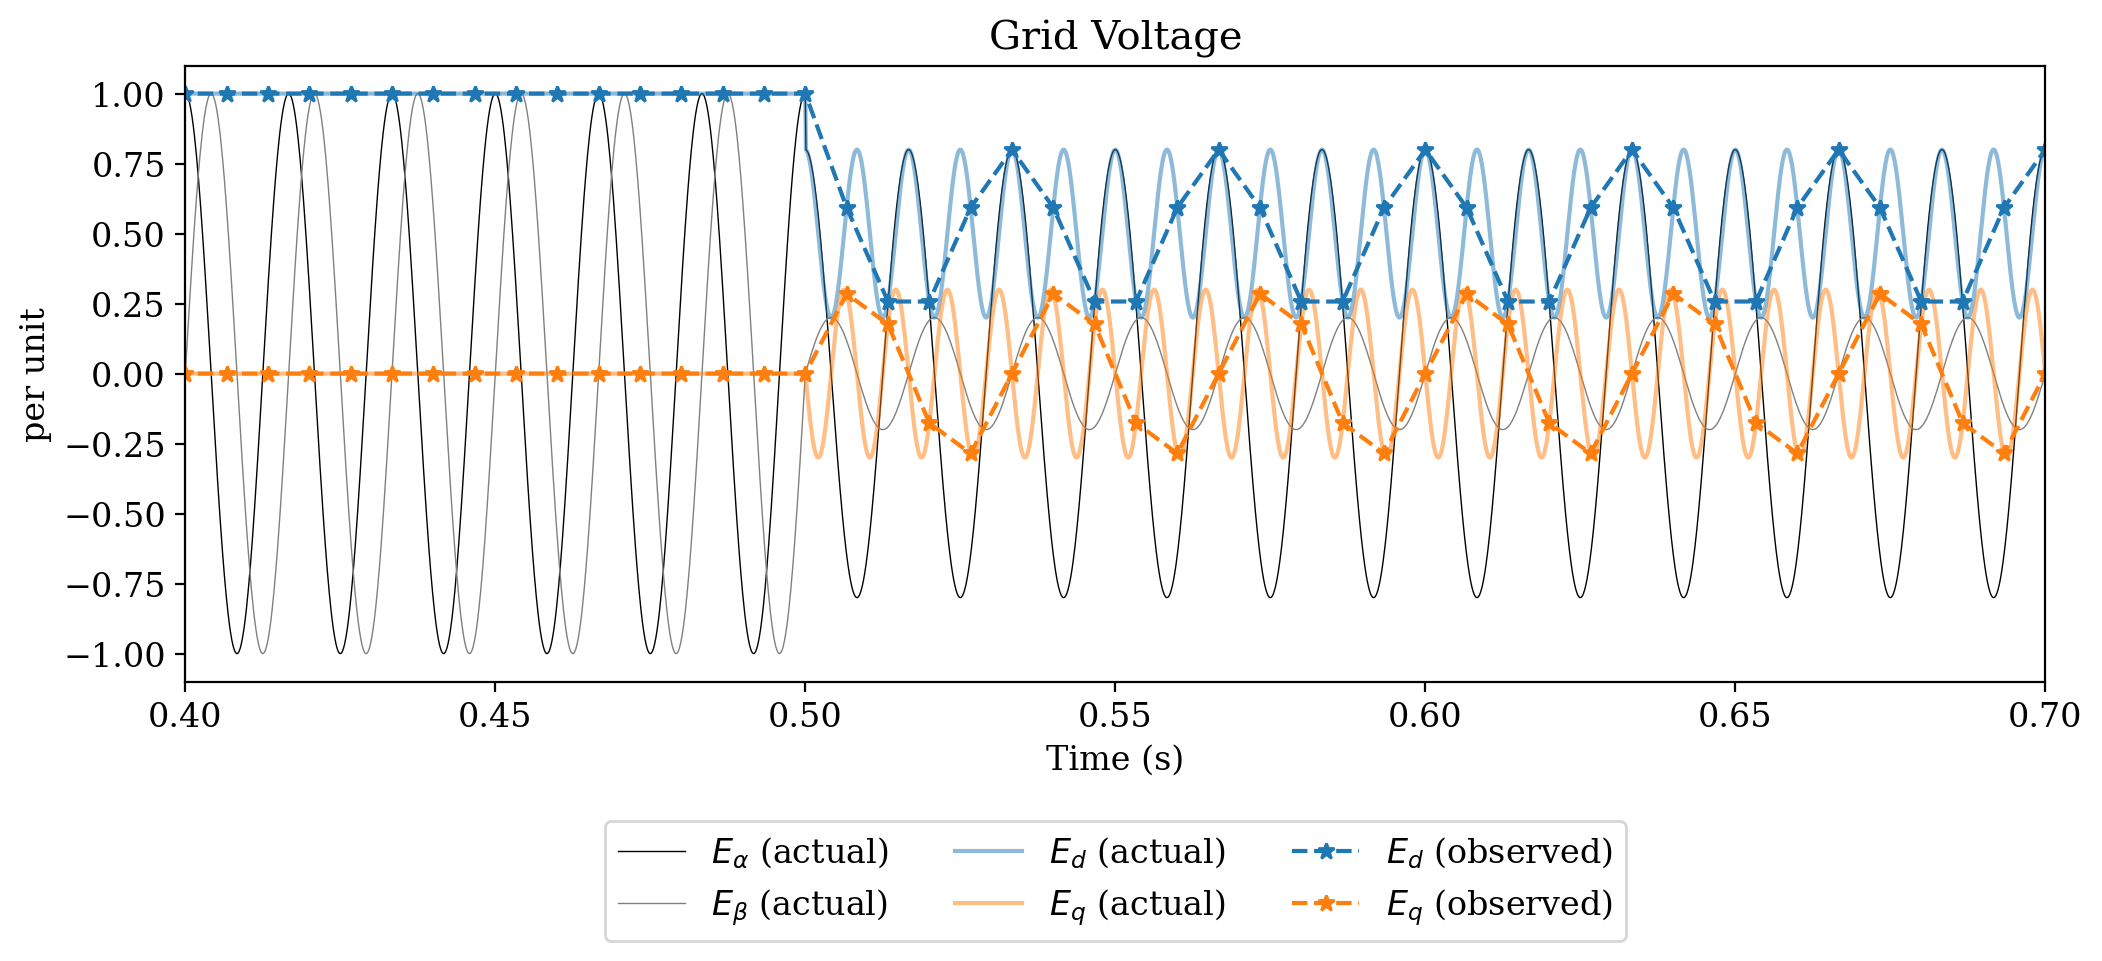

In [78]:
fig,(ax1) = plt.subplots(1,1,figsize=(12,4))

# Stationary frame plot of grid voltage
ax1.plot(ts_abc, Vg_alphabeta[0,:],c='black',label=r"$E_\alpha$ (actual)",linewidth=0.5)
ax1.plot(ts_abc, Vg_alphabeta[1,:],c='gray',label=r"$E_\beta$ (actual)",linewidth=0.5)
ax1.plot(ts_abc, Vg_d,c="C0",label=r"$E_d$ (actual)",alpha=0.5)
ax1.plot(ts_abc, Vg_q,c="C1",label=r"$E_q$ (actual)",alpha=0.5)
ax1.plot(ts_oc, Vg_d_ctrl,c="C0",marker="*",linestyle="dashed",label=r"$E_d$ (observed)")
ax1.plot(ts_oc, Vg_q_ctrl,c="C1",marker="*",linestyle="dashed",label=r"$E_q$ (observed)")
ax1.set_title("Grid Voltage")
ax1.set_ylabel("per unit")
ax1.set_xlabel("Time (s)")
ax1.set_xlim([0.4,0.7])
ax1.legend(loc="upper center",
    bbox_to_anchor=(0.5, -0.2),
    ncol=3)


plt.show()

# C. Setpoint change in 14 bus (reduced) network

### 1. Load 14 bus test system and run powerflow

In [4]:
net14 = case14()
base_mva = net14["baseMVA"]
nb = net14["bus"].shape[0]
nbr = net14["branch"].shape[0]
# Initialize "inverters" at non-zero power before solving powerflow
net14["gen"][:,PG] = np.array([60,90,90,90,90])

# Find equilibrium point (run power flow) to initialize simulation
pf_result, success = runpf(net14)

PYPOWER Version 5.1.18, 10-Apr-2025 -- AC Power Flow (Newton)


Newton's method power flow converged in 4 iterations.

Converged in 0.02 seconds
|     System Summary                                                           |

How many?                How much?              P (MW)            Q (MVAr)
---------------------    -------------------  -------------  -----------------
Buses             14     Total Gen Capacity     772.4         -52.0 to 148.0
Generators         5     On-line Capacity       772.4         -52.0 to 148.0
Committed Gens     5     Generation (actual)    261.9              59.2
Loads             11     Load                   259.0              73.5
  Fixed           11       Fixed                259.0              73.5
  Dispatchable     0       Dispatchable           0.0 of 0.0        0.0
Shunts             1     Shunt (inj)             -0.0              21.2
Branches          20     Losses (I^2 * Z)         2.94             31.56
Transformers       3     Branch 

### 2. Choose inverter filter parameters

In [5]:
inverter_bus_ids = np.array(net14["gen"][:,GEN_BUS],dtype=int)
slack_id = inverter_bus_ids[0]
inverter_bus_ids = inverter_bus_ids[1:]
filter_xs = np.ones(len(inverter_bus_ids)) * 0.1 # in per unit
filter_rs = np.ones(len(inverter_bus_ids)) * 0.01 # in per unit

### 3. Construct Ybus matrix

In [6]:
Ybus = mc.create_Ybus(net14, pf_result)
Ybus_KRONdq, Y_slackdq = mc.Kron_reduce(Ybus, slack_id-1, inverter_bus_ids-1)

### 4. Simulate

#### Example: Increase power setpoint for inverter 1 to violate current limit

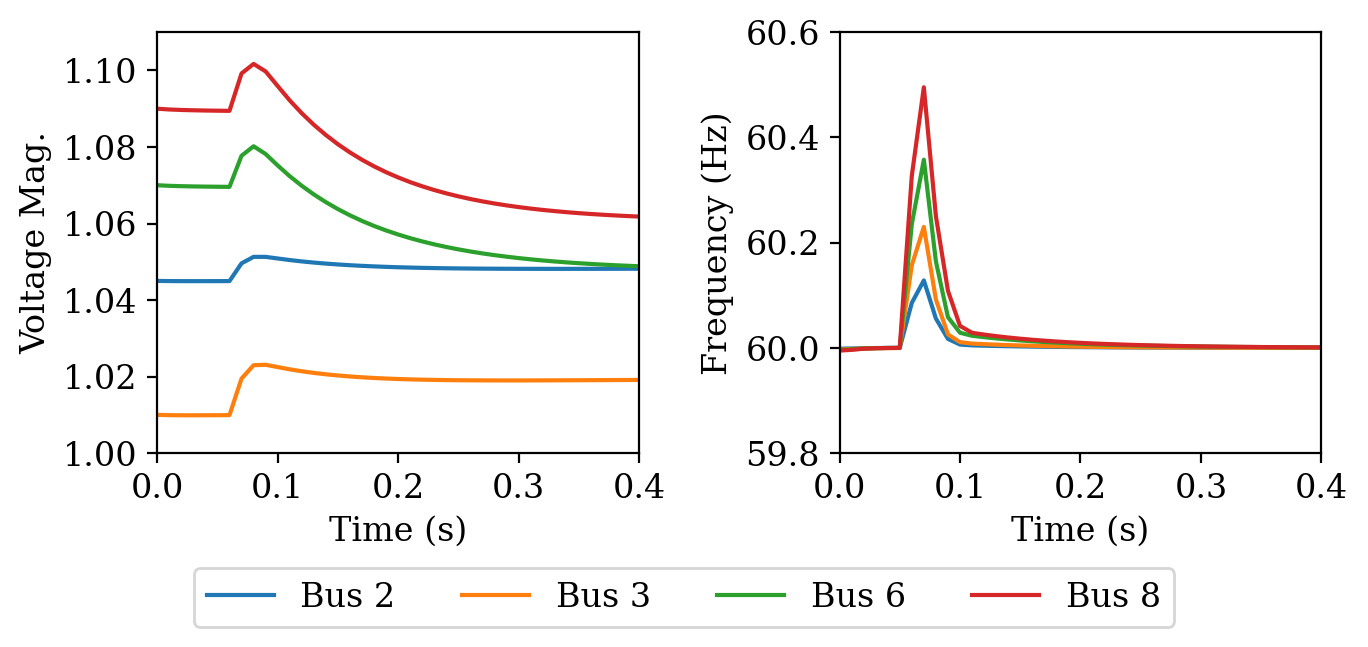

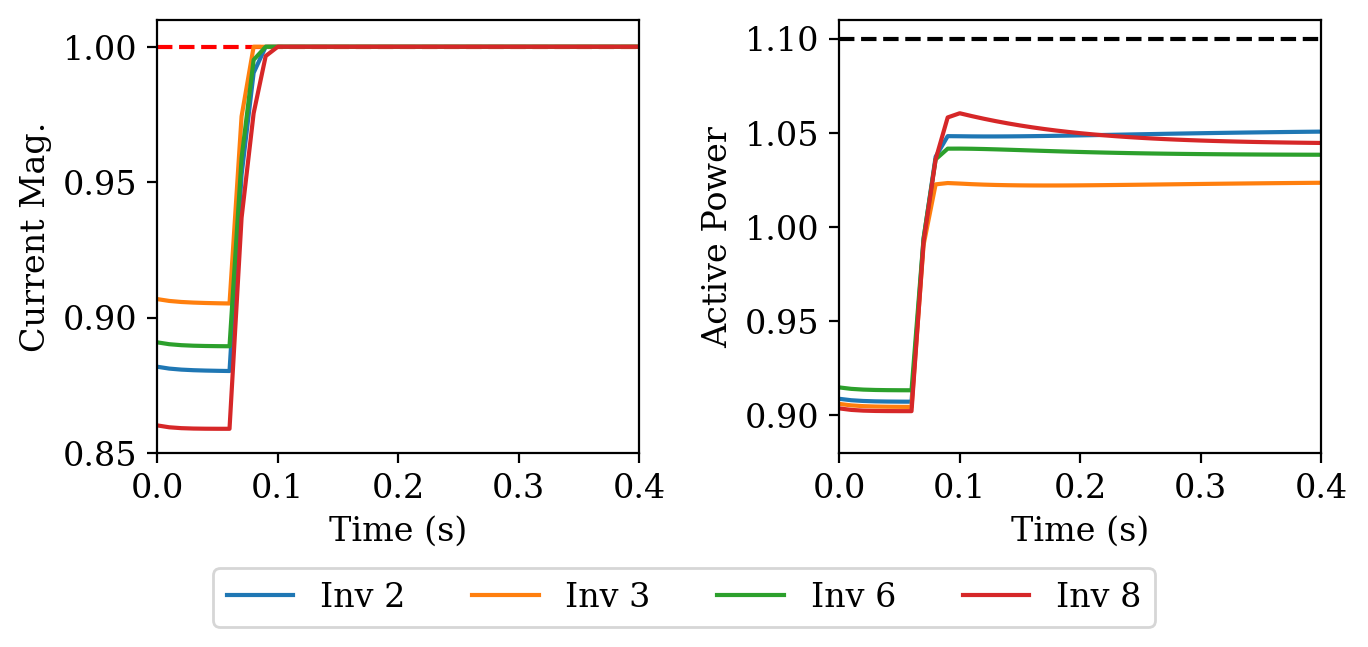

In [15]:
starttime=0.05
endtime = 1
dt = 1e-2
rho = 0.001
alpha = 2

Ps0, Qs0, V2s0 = mc.initial_setpoints(slack_id, inverter_bus_ids, pf_result,Ybus_KRONdq, Y_slackdq, filter_rs, filter_xs)

gen_mask = np.isin(pf_result["gen"][:,GEN_BUS], inverter_bus_ids)
inverter_setpoints = np.vstack((Ps0, V2s0)).T
inverter_setpoints[:,0] = 1.1 * np.ones(len(Ps0))
inverter_varnames = np.array([["P",r"$V^2$"],["P",r"$V^2$"],["P",r"$V^2$"],["P",r"$V^2$"]]) # variables corresponding to setpoints in above array
inverter_mag_limits = np.ones(len(inverter_bus_ids)) # all limited to 1 pu? check what this value should be - possibly smaller since baseMVA is large

bus_labels = np.array([2,3,6,8]) # the bus IDs for the inverters

ts, Iinvs, Vinvs, Vgs, Ps, Qs = mc.multi_inv_simulation(slack_id, inverter_bus_ids, inverter_setpoints, inverter_varnames, 
                         inverter_mag_limits, pf_result, 
                         Ybus_KRONdq, Y_slackdq, filter_rs, filter_xs,
                         rho=rho, alpha=alpha,
                         dt=dt, starttime = starttime, endtime=endtime)

# Plot voltage magnitude and frequency (network voltages)
n_steps = len(ts)
n_inv = len(inverter_bus_ids)
Vg_mag_data = np.linalg.norm(Vgs.reshape(n_steps,n_inv,2),axis=2)
Vg_angle_data, Vg_frequency_data = plot.angle_and_frequency(Vgs, dt)
Vg_frequency_data = (Vg_frequency_data+2*np.pi*60)/(2*np.pi) # convert to rotating frame and to Hz

fig,(ax1,ax2) = plt.subplots(1,2,figsize=(7,3), sharex=True)
plot.plot_multi_inverters(ts, Vg_mag_data, r"Voltage Mag.", "Bus", xlim=None, inv_labels = bus_labels, ax=ax1, show_legend=False)
plot.plot_multi_inverters(ts, Vg_frequency_data, "Frequency (Hz)", "Bus", xlim=None, inv_labels = bus_labels, ax=ax2, show_legend=False)
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=n_inv, bbox_to_anchor=(0.5, -0.1))
ax1.set_ylim([1.0,1.11])
ax2.set_ylim([59.8,60.6])
ax1.set_xlim([0,0.4])
ax2.set_xlim([0,0.4])
plt.tight_layout()
plt.show()

Ii_mag_data = np.linalg.norm(Iinvs.reshape(n_steps,n_inv,2),axis=2)
Ps_setpoints = np.ones((len(ts), n_inv)) * inverter_setpoints[:,0]
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(7,3), sharex=True)
ax1.plot(ts, np.ones(len(ts)), "r--") # Plot current limit
plot.plot_multi_inverters(ts, Ii_mag_data, r"Current Mag.", "Inv", inv_labels = bus_labels, xlim=None, ax=ax1, show_legend=False)
ax2.plot(ts, inverter_setpoints[0,0] * np.ones(len(ts)), "k--") # Plot power setpoint 
plot.plot_multi_inverters(ts, Ps, r"Active Power", "Inv", xlim=None, ax=ax2, inv_labels = bus_labels, show_legend=False)
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=n_inv, bbox_to_anchor=(0.5, -0.1))
ax1.set_ylim([0.85,1.01])
ax2.set_ylim([0.88,1.11])
ax1.set_xlim([0,0.4])
ax2.set_xlim([0,0.4])
plt.tight_layout()
plt.show()

#### Same example with slower dt

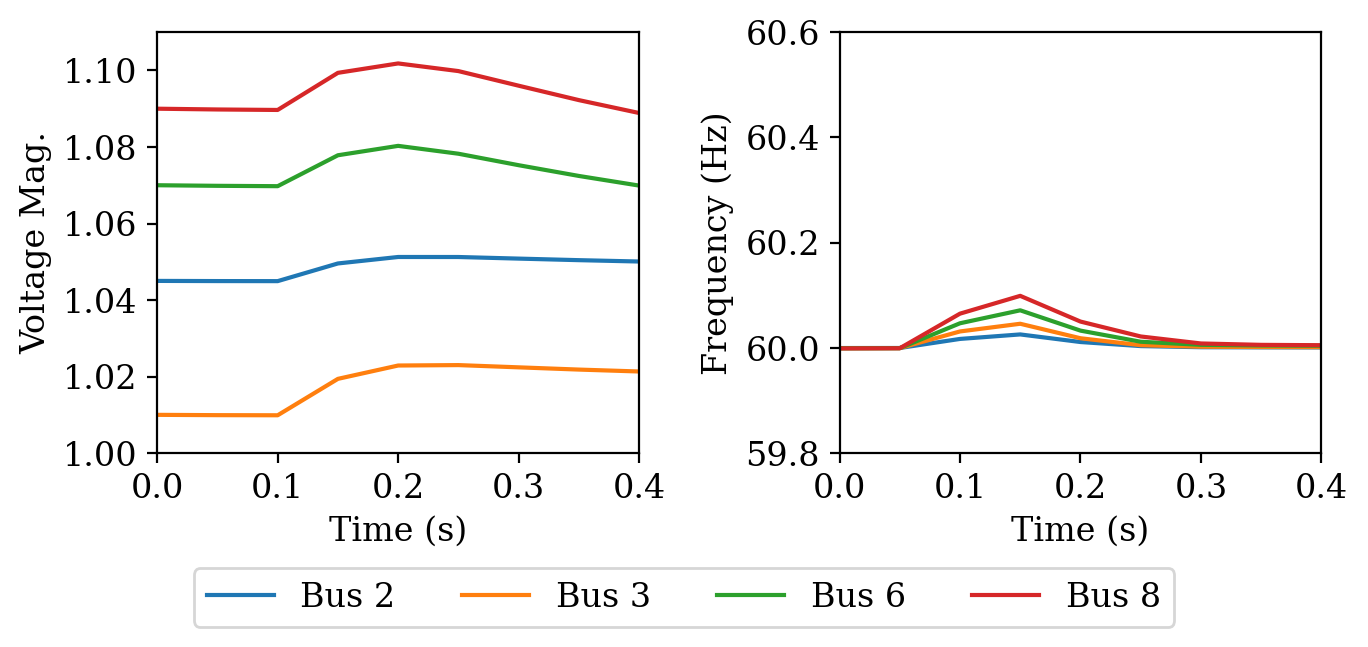

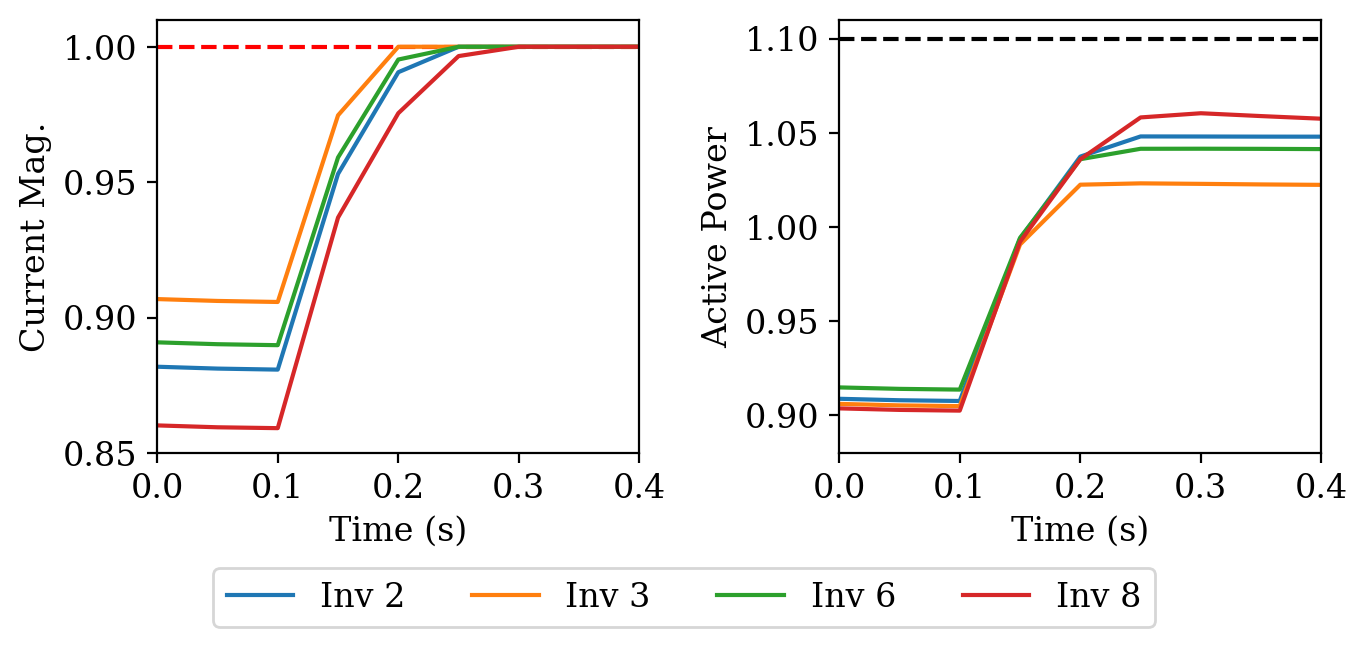

In [18]:
starttime=0.05
endtime = 1
dt = 5e-2
rho = 0.001
alpha = 2

Ps0, Qs0, V2s0 = mc.initial_setpoints(slack_id, inverter_bus_ids, pf_result,Ybus_KRONdq, Y_slackdq, filter_rs, filter_xs)

gen_mask = np.isin(pf_result["gen"][:,GEN_BUS], inverter_bus_ids)
inverter_setpoints = np.vstack((Ps0, V2s0)).T
inverter_setpoints[:,0] = 1.1 * np.ones(len(Ps0))
inverter_varnames = np.array([["P",r"$V^2$"],["P",r"$V^2$"],["P",r"$V^2$"],["P",r"$V^2$"]]) # variables corresponding to setpoints in above array
inverter_mag_limits = np.ones(len(inverter_bus_ids)) # all limited to 1 pu? check what this value should be - possibly smaller since baseMVA is large

ts, Iinvs, Vinvs, Vgs, Ps, Qs = mc.multi_inv_simulation(slack_id, inverter_bus_ids, inverter_setpoints, inverter_varnames, 
                         inverter_mag_limits, pf_result, 
                         Ybus_KRONdq, Y_slackdq, filter_rs, filter_xs,
                         rho=rho, alpha=alpha,
                         dt=dt, starttime = starttime, endtime=endtime)

# Plot voltage magnitude and frequency (network voltages)
n_steps = len(ts)
n_inv = len(inverter_bus_ids)
Vg_mag_data = np.linalg.norm(Vgs.reshape(n_steps,n_inv,2),axis=2)
Vg_angle_data, Vg_frequency_data = plot.angle_and_frequency(Vgs, dt)
Vg_frequency_data = (Vg_frequency_data+2*np.pi*60)/(2*np.pi) # convert to rotating frame and to Hz

fig,(ax1,ax2) = plt.subplots(1,2,figsize=(7,3), sharex=True)
plot.plot_multi_inverters(ts, Vg_mag_data, r"Voltage Mag.", "Bus", xlim=None, inv_labels = bus_labels, ax=ax1, show_legend=False)
plot.plot_multi_inverters(ts, Vg_frequency_data, "Frequency (Hz)", "Bus", xlim=None, inv_labels = bus_labels, ax=ax2, show_legend=False)
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=n_inv, bbox_to_anchor=(0.5, -0.1))
ax1.set_ylim([1.0,1.11])
ax2.set_ylim([59.8,60.6])
ax1.set_xlim([0,0.4])
ax2.set_xlim([0,0.4])
plt.tight_layout()
plt.show()

Ii_mag_data = np.linalg.norm(Iinvs.reshape(n_steps,n_inv,2),axis=2)
Ps_setpoints = np.ones((len(ts), n_inv)) * inverter_setpoints[:,0]
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(7,3), sharex=True)
ax1.plot(ts, np.ones(len(ts)), "r--") # Plot current limit
plot.plot_multi_inverters(ts, Ii_mag_data, r"Current Mag.", "Inv", inv_labels = bus_labels, xlim=None, ax=ax1, show_legend=False)
ax2.plot(ts, inverter_setpoints[0,0] * np.ones(len(ts)), "k--") # Plot power setpoint 
plot.plot_multi_inverters(ts, Ps, r"Active Power", "Inv", xlim=None, ax=ax2, inv_labels = bus_labels, show_legend=False)
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=n_inv, bbox_to_anchor=(0.5, -0.1))
ax1.set_ylim([0.85,1.01])
ax2.set_ylim([0.88,1.11])
ax1.set_xlim([0,0.4])
ax2.set_xlim([0,0.4])
plt.tight_layout()
plt.show()